# Modelos de Machine Learning
## Solución Inteligente de Seguridad Ciudadana para Santander

**Objetivo:** Implementar un sistema híbrido de predicción de criminalidad que integra tres módulos complementarios:

1. **Módulo Temporal**: Predicción de tendencias y patrones temporales
2. **Módulo Espacial**: Identificación de hotspots y análisis geográfico
3. **Módulo de Riesgo**: Clasificación y scoring de riesgo por zona-tiempo

**Arquitectura del Sistema:**
```
┌─────────────────────────────────────────────────────────┐
│          SISTEMA INTEGRADO DE PREDICCIÓN                │
└─────────────────────────────────────────────────────────┘
                          │
          ┌───────────────┼───────────────┐
          │               │               │
          ▼               ▼               ▼
    ┌─────────┐    ┌──────────┐    ┌─────────┐
    │ Módulo  │    │  Módulo  │    │ Módulo  │
    │Temporal │    │ Espacial │    │  Riesgo │
    └─────────┘    └──────────┘    └─────────┘
    SARIMA +       DBSCAN +         XGBoost
    Prophet        KDE              Classifier
         │              │                │
         └──────────────┼────────────────┘
                        ▼
              ┌──────────────────┐
              │ ENSEMBLE FINAL   │
              │ (Integración)    │
              └──────────────────┘
```

**Fecha de desarrollo:** Noviembre 19, 2025
**Datasets base:** Resultados del EDA (eda.ipynb)

## 📋 Tabla de Contenido

### FASE 1: Preparación de Datos
1. [Configuración Inicial](#1-configuracion)
2. [Carga y Preprocesamiento de Datos](#2-carga-datos)
3. [Ingeniería de Features](#3-feature-engineering)

### FASE 2: Módulo Temporal
4. [Preparación de Series Temporales](#4-prep-temporal)
5. [Modelo SARIMA](#5-sarima)
6. [Modelo Prophet](#6-prophet)
7. [Evaluación Módulo Temporal](#7-eval-temporal)

### FASE 3: Módulo Espacial
8. [Preparación de Datos Geográficos](#8-prep-espacial)
9. [Clustering con DBSCAN](#9-dbscan)
10. [Mapas de Calor con KDE](#10-kde)
11. [Evaluación Módulo Espacial](#11-eval-espacial)

### FASE 4: Módulo de Riesgo
12. [Preparación de Features para Clasificación](#12-prep-riesgo)
13. [Modelo XGBoost](#13-xgboost)
14. [Optimización de Hiperparámetros](#14-optimizacion)
15. [Evaluación Módulo de Riesgo](#15-eval-riesgo)

### FASE 5: Integración y Deployment
16. [Sistema Ensemble](#16-ensemble)
17. [Validación del Sistema Completo](#17-validacion)
18. [Exportación de Modelos](#18-export)
19. [Dashboard de Resultados](#19-dashboard)

---

# FASE 1: PREPARACIÓN DE DATOS

---

## 1. Configuración Inicial e Importación de Librerías <a id='1-configuracion'></a>

In [1]:
# ============================================================================
# LIBRERÍAS GENERALES
# ============================================================================
import pandas as pd
import numpy as np
import warnings
import os
import pickle
import json
from datetime import datetime, timedelta
from dotenv import load_dotenv
from pathlib import Path

# ============================================================================
# VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================================
# MODELOS DE SERIES TEMPORALES
# ============================================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# ============================================================================
# MODELOS DE CLUSTERING Y ANÁLISIS ESPACIAL
# ============================================================================
from sklearn.cluster import DBSCAN, KMeans
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist

# ============================================================================
# MODELOS DE CLASIFICACIÓN Y REGRESIÓN
# ============================================================================
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ============================================================================
# PREPROCESAMIENTO Y FEATURE ENGINEERING
# ============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ============================================================================
# MÉTRICAS DE EVALUACIÓN
# ============================================================================
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
)

# ============================================================================
# MANEJO DE DESBALANCEO DE CLASES
# ============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Cargar variables de entorno
load_dotenv()
APP_TOKEN = os.getenv('AppToken')

# Configuración de visualizaciones
FIGSIZE_LARGE = (16, 8)
FIGSIZE_MEDIUM = (12, 6)
FIGSIZE_SMALL = (10, 5)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas exitosamente")
print(f"✅ Numpy: {np.__version__}")
print(f"✅ Pandas: {pd.__version__}")
print(f"✅ Random State: {RANDOM_STATE}")

✅ Librerías importadas exitosamente
✅ Numpy: 2.3.5
✅ Pandas: 2.3.3
✅ Random State: 42


## 2. Carga de Datos Procesados <a id='2-carga-datos'></a>

### 2.1. Cargar Datasets desde pipelines.ipynb

Cargamos los datasets procesados en formato Parquet que contienen:
- ✅ Todas las features de ingeniería temporal, espacial y categórica
- ✅ Nombres de columnas preservados
- ✅ Tipos de datos correctos (datetime, int, float)
- ✅ Listo para entrenar modelos sin preprocesamiento adicional

In [2]:
print("="*80)
print("CARGANDO DATASETS PROCESADOS DESDE PARQUET")
print("="*80)

# Ruta a la carpeta de datasets procesados
processed_folder = Path('datasets/processed')

# Verificar que exista
if not processed_folder.exists():
    raise FileNotFoundError(
        f"❌ La carpeta '{processed_folder}' no existe.\n"
        "   Por favor, ejecute primero pipelines.ipynb para generar los datos procesados."
    )

# Cargar metadata de procesamiento
metadata_path = processed_folder / 'processing_metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        processing_metadata = json.load(f)
    
    print(f"\n📋 Metadata cargada:")
    print(f"   Fecha procesamiento: {processing_metadata['fecha_procesamiento']}")
    print(f"   Formato: {processing_metadata['formato']}")
    print(f"   Compresión: {processing_metadata['compresion']}")
else:
    print("\n⚠️ No se encontró archivo de metadata")
    processing_metadata = None

# Cargar cada dataset procesado
print(f"\n📂 Cargando datasets procesados...\n")

datasets = {}

dataset_files = {
    'delitos_bucaramanga': 'delitos_bucaramanga_processed.parquet',
    'info_delictiva_bucaramanga': 'info_delictiva_bucaramanga_processed.parquet',
    'delitos_sexuales': 'delitos_sexuales_processed.parquet',
    'violencia_intrafamiliar': 'violencia_intrafamiliar_processed.parquet',
    'hurto_modalidades': 'hurto_modalidades_processed.parquet'
}

for key, filename in dataset_files.items():
    filepath = processed_folder / filename
    
    if filepath.exists():
        # Cargar Parquet
        df = pd.read_parquet(filepath)
        datasets[key] = df
        
        print(f"✅ {key}")
        print(f"   Archivo: {filename}")
        print(f"   Shape: {df.shape}")
        print(f"   Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"   Columnas: {len(df.columns)}")
        print()
    else:
        print(f"⚠️ No encontrado: {filename}\n")

print(f"{'='*80}")
print("✅ DATASETS PROCESADOS CARGADOS")
print(f"{'='*80}")

print(f"\n📊 Total datasets: {len(datasets)}")
print(f"📊 Total registros: {sum(len(df) for df in datasets.values()):,}")

# Mostrar resumen
print(f"\n📋 RESUMEN:\n")
summary_data = []
for key, df in datasets.items():
    summary_data.append({
        'Dataset': key,
        'Registros': f"{len(df):,}",
        'Columnas': len(df.columns),
        'Memoria_MB': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

CARGANDO DATASETS PROCESADOS DESDE PARQUET

📋 Metadata cargada:
   Fecha procesamiento: 2025-11-20T16:42:12.292772
   Formato: parquet
   Compresión: snappy

📂 Cargando datasets procesados...

✅ delitos_bucaramanga
   Archivo: delitos_bucaramanga_processed.parquet
   Shape: (135076, 37)
   Memoria: 135.61 MB
   Columnas: 37

✅ info_delictiva_bucaramanga
   Archivo: info_delictiva_bucaramanga_processed.parquet
   Shape: (120723, 55)
   Memoria: 151.82 MB
   Columnas: 55

✅ delitos_sexuales
   Archivo: delitos_sexuales_processed.parquet
   Shape: (19978, 30)
   Memoria: 11.99 MB
   Columnas: 30

✅ violencia_intrafamiliar
   Archivo: violencia_intrafamiliar_processed.parquet
   Shape: (50864, 27)
   Memoria: 24.40 MB
   Columnas: 27

✅ hurto_modalidades
   Archivo: hurto_modalidades_processed.parquet
   Shape: (1422, 30)
   Memoria: 0.79 MB
   Columnas: 30

✅ DATASETS PROCESADOS CARGADOS

📊 Total datasets: 5
📊 Total registros: 328,063

📋 RESUMEN:



,Dataset,Registros,Columnas,Memoria_MB
0,delitos_bucaramanga,"135,076",37,135.61
1,info_delictiva_bucaramanga,"120,723",55,151.82
2,delitos_sexuales,"19,978",30,11.99
3,violencia_intrafamiliar,"50,864",27,24.40
4,hurto_modalidades,"1,422",30,0.79


In [3]:
# Mostrar información de los features disponibles por dataset
print("="*80)
print("FEATURES DISPONIBLES POR DATASET")
print("="*80)

for dataset_name, df in datasets.items():
    print(f"\n📊 {dataset_name.upper()}")
    print("-"*80)
    
    # Identificar tipos de features
    temporal_features = [col for col in df.columns if any(x in col.lower() for x in ['año', 'mes', 'dia', 'semana', 'trimestre', 'semestre', 'fecha'])]
    spatial_features = [col for col in df.columns if any(x in col for x in ['lat', 'lon', 'zona', 'grid', 'dist'])]
    encoded_features = [col for col in df.columns if col.endswith('_encoded') or col.endswith('_freq')]
    agg_features = [col for col in df.columns if any(x in col for x in ['count', 'rolling', 'mean', 'std'])]
    
    print(f"📅 Features temporales ({len(temporal_features)}): {temporal_features[:5] if temporal_features else 'Ninguna'}...")
    print(f"🗺️ Features espaciales ({len(spatial_features)}): {spatial_features[:5] if spatial_features else 'Ninguna'}...")
    print(f"🏷️ Features codificadas ({len(encoded_features)}): {encoded_features[:5] if encoded_features else 'Ninguna'}...")
    print(f"📊 Features agregadas ({len(agg_features)}): {agg_features[:5] if agg_features else 'Ninguna'}...")
    print(f"\n✅ Total columnas: {len(df.columns)}")

print(f"\n{'='*80}")
print("DATOS LISTOS PARA ENTRENAR MODELOS")
print(f"{'='*80}")

FEATURES DISPONIBLES POR DATASET

📊 DELITOS_BUCARAMANGA
--------------------------------------------------------------------------------
📅 Features temporales (4): ['mes', 'dia', 'dia_semana', 'dia_semana_encoded']...
🗺️ Features espaciales (9): ['latitud', 'longitud', 'zona', 'lat_grid', 'lon_grid']...
🏷️ Features codificadas (12): ['armas_medios_encoded', 'barrios_hecho_encoded', 'zona_encoded', 'nom_comuna_encoded', 'conducta_encoded']...
📊 Features agregadas (2): ['count_by_zona_id', 'count_by_barrios_hecho']...

✅ Total columnas: 37

📊 INFO_DELICTIVA_BUCARAMANGA
--------------------------------------------------------------------------------
📅 Features temporales (17): ['fecha_hecho', 'mes_num', 'dia_num', 'dia_nombre', 'dia_nombre_orden']...
🗺️ Features espaciales (0): Ninguna...
🏷️ Features codificadas (14): ['descripcion_conducta_encoded', 'armas_medios_encoded', 'barrios_hecho_encoded', 'sexo_encoded', 'movil_victima_encoded']...
📊 Features agregadas (3): ['barrio_delitos_coun

### 2.2. Verificación de Features Disponibles

Verificamos que los datasets procesados contengan todas las features necesarias para el entrenamiento


---

# FASE 2: MÓDULO TEMPORAL - PREDICCIÓN CON PROPHET

---

## 4. Preparación de Series Temporales <a id='4-prep-temporal'></a>

Crearemos series temporales a partir del dataset principal `info_delictiva_bucaramanga` que contiene fechas completas.

In [32]:
# ============================================================================
# MÓDULO TEMPORAL: PREPARACIÓN DE DATOS
# ============================================================================
print("="*80)
print("MÓDULO TEMPORAL: PREPARACIÓN DE SERIES TEMPORALES")
print("="*80)

# Trabajar con info_delictiva_bucaramanga procesado (tiene fecha_hecho como datetime)
df_info = datasets['info_delictiva_bucaramanga'].copy()

print("\n📊 Preparando datos de 'info_delictiva_bucaramanga'")
print(f"   Registros totales: {len(df_info):,}")
print(f"   Columnas disponibles: {len(df_info.columns)}")

# Eliminar registros sin fecha válida
df_temporal = df_info[df_info['fecha_hecho'].notna()].copy()
print(f"   Registros con fecha válida: {len(df_temporal):,} ({len(df_temporal)/len(df_info)*100:.1f}%)")

# Estadísticas de rango temporal
fecha_min = df_temporal['fecha_hecho'].min()
fecha_max = df_temporal['fecha_hecho'].max()
dias_totales = (fecha_max - fecha_min).days

print(f"\n📅 Rango temporal:")
print(f"   Fecha inicial: {fecha_min.strftime('%Y-%m-%d')}")
print(f"   Fecha final: {fecha_max.strftime('%Y-%m-%d')}")
print(f"   Días totales: {dias_totales:,} días ({dias_totales/365:.1f} años)")

# Agregación diaria (contar delitos por día)
daily_counts = df_temporal.groupby('fecha_hecho').size().reset_index()
daily_counts.columns = ['ds', 'y']  # Prophet requiere estas columnas exactas

print(f"\n📈 Serie temporal agregada:")
print(f"   Días con al menos un delito: {len(daily_counts):,}")
print(f"   Promedio de delitos por día: {daily_counts['y'].mean():.2f}")
print(f"   Máximo de delitos en un día: {daily_counts['y'].max()}")
print(f"   Mínimo de delitos en un día: {daily_counts['y'].min()}")

# Completar fechas faltantes (días sin delitos = 0 delitos)
date_range = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
daily_counts_complete = pd.DataFrame({'ds': date_range})
daily_counts_complete = daily_counts_complete.merge(daily_counts, on='ds', how='left')
daily_counts_complete['y'] = daily_counts_complete['y'].fillna(0).astype(int)

print(f"\n✅ Serie temporal completa (con ceros):")
print(f"   Total de días: {len(daily_counts_complete):,}")
print(f"   Días sin delitos: {(daily_counts_complete['y'] == 0).sum():,}")
print(f"   Días con delitos: {(daily_counts_complete['y'] > 0).sum():,}")

# Visualización rápida de la distribución
print(f"\n📊 Distribución de delitos diarios:")
print(daily_counts_complete['y'].describe())

# Guardar serie temporal para uso posterior
ts_data = daily_counts_complete.copy()

print(f"\n{'='*80}")
print("✅ PREPARACIÓN DE SERIE TEMPORAL COMPLETADA")

print(f"{'='*80}")

MÓDULO TEMPORAL: PREPARACIÓN DE SERIES TEMPORALES

📊 Preparando datos de 'info_delictiva_bucaramanga'
   Registros totales: 120,723
   Columnas disponibles: 55
   Registros con fecha válida: 120,723 (100.0%)

📅 Rango temporal:
   Fecha inicial: 2016-01-01
   Fecha final: 2025-05-31
   Días totales: 3,438 días (9.4 años)

📈 Serie temporal agregada:
   Días con al menos un delito: 3,439
   Promedio de delitos por día: 35.10
   Máximo de delitos en un día: 84
   Mínimo de delitos en un día: 4

✅ Serie temporal completa (con ceros):
   Total de días: 3,439
   Días sin delitos: 0
   Días con delitos: 3,439

📊 Distribución de delitos diarios:
count    3439.000000
mean       35.104100
std        10.476333
min         4.000000
25%        28.000000
50%        34.000000
75%        42.000000
max        84.000000
Name: y, dtype: float64

✅ PREPARACIÓN DE SERIE TEMPORAL COMPLETADA


## 5. Visualización de Serie Temporal

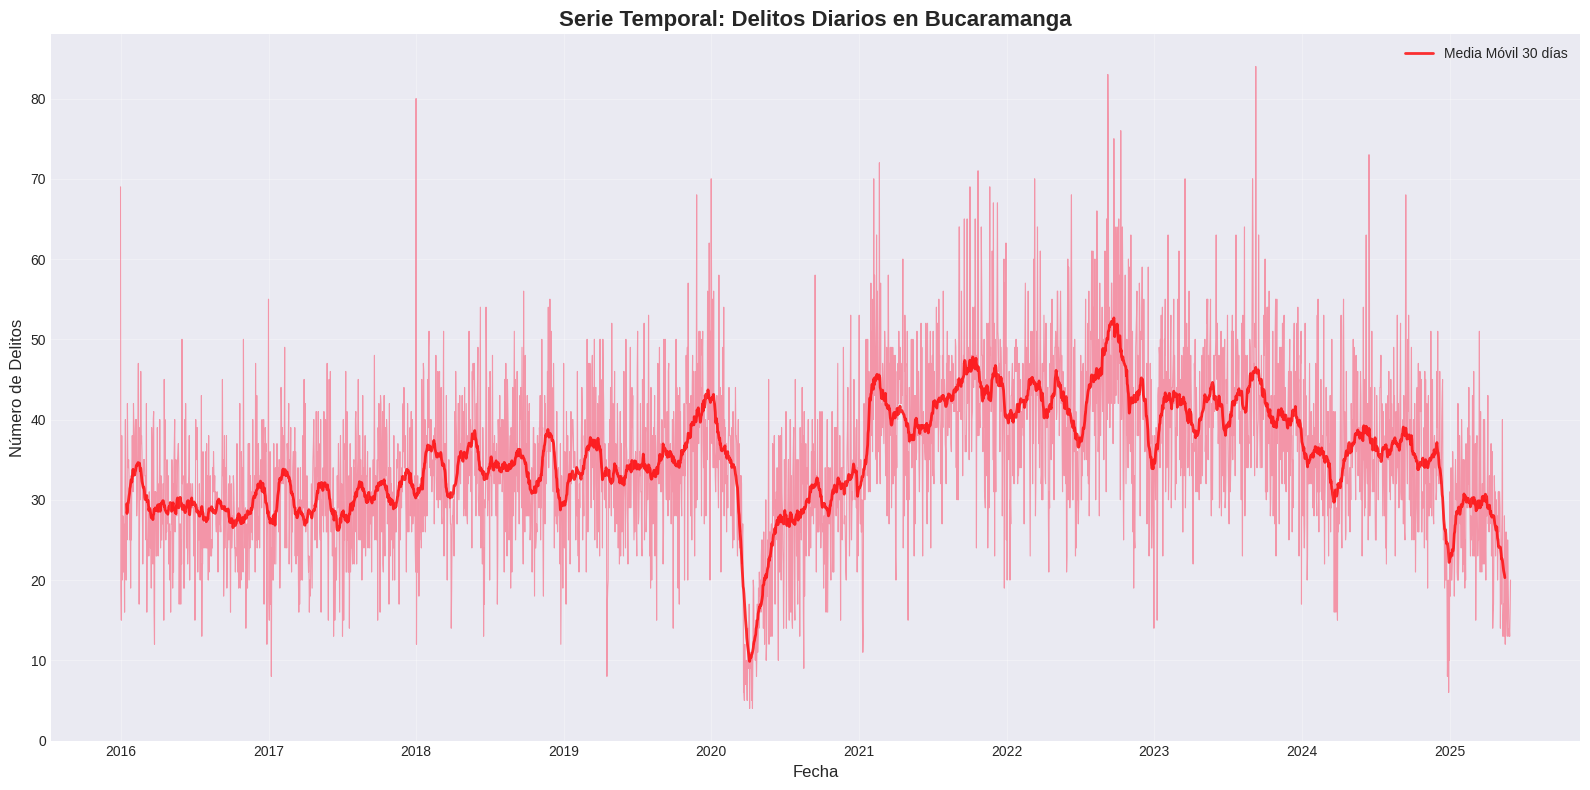

📈 Serie temporal visualizada con promedio móvil


In [33]:
# Visualizar la serie temporal
fig = plt.figure(figsize=FIGSIZE_LARGE)

plt.plot(ts_data['ds'], ts_data['y'], linewidth=0.8, alpha=0.7)
plt.title('Serie Temporal: Delitos Diarios en Bucaramanga', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Delitos', fontsize=12)
plt.grid(True, alpha=0.3)

# Promedio móvil de 30 días
ts_data['ma_30'] = ts_data['y'].rolling(window=30, center=True).mean()
plt.plot(ts_data['ds'], ts_data['ma_30'], 'r-', linewidth=2, label='Media Móvil 30 días', alpha=0.8)

plt.legend()
plt.tight_layout()
plt.show()

print(f"📈 Serie temporal visualizada con promedio móvil")


## 6. Modelo Prophet <a id='6-prophet'></a>

Prophet es un modelo de series temporales desarrollado por Facebook que maneja automáticamente:
- Tendencias
- Estacionalidades múltiples (anual, semanal, diaria)
- Festivos y eventos especiales
- Valores faltantes

**Ventajas para nuestro caso:**
- ✅ Fácil de usar e interpretar
- ✅ Maneja automáticamente estacionalidad
- ✅ Robusto a datos faltantes
- ✅ Incorpora festivos colombianos

In [34]:
# ============================================================================
# ENTRENAMIENTO DE MODELO PROPHET - VERSIÓN ORIGINAL
# ============================================================================
print("="*80)
print("ENTRENAMIENTO DEL MODELO PROPHET - VERSIÓN ORIGINAL")
print("="*80)

# Configurar modelo Prophet ORIGINAL
print("\n🔧 Configurando modelo Prophet ORIGINAL...")
model_prophet = Prophet(
    yearly_seasonality=True,      # Patrones anuales
    weekly_seasonality=True,       # Patrones semanales
    daily_seasonality=False,       # No tenemos hora del día
    changepoint_prior_scale=0.05,  # Flexibilidad de tendencia (0.05 es conservador)
    seasonality_prior_scale=10.0,  # Fuerza de estacionalidad
    interval_width=0.95,           # Intervalo de confianza al 95%
    seasonality_mode='multiplicative'  # Los patrones estacionales se multiplican con la tendencia
)

# Añadir festivos colombianos automáticamente
print("   Añadiendo festivos colombianos...")
model_prophet.add_country_holidays(country_name='CO')

print("✅ Modelo configurado con:")
print("   • Estacionalidad anual: Sí")
print("   • Estacionalidad semanal: Sí")
print("   • Festivos Colombia: Sí")
print("   • Intervalo confianza: 95%")

# Entrenar modelo
print("\n🚀 Entrenando modelo Prophet...")
print("   (Esto puede tomar varios minutos...)")

model_prophet.fit(ts_data)

print("✅ Modelo entrenado exitosamente")

# Generar predicciones futuras
print("\n📊 Generando predicciones futuras...")

# Predicciones para los próximos 90 días
future_periods = 90
future = model_prophet.make_future_dataframe(periods=future_periods, freq='D')

print(f"   Prediciendo {future_periods} días hacia el futuro")
print(f"   Última fecha histórica: {ts_data['ds'].max().strftime('%Y-%m-%d')}")
print(f"   Última fecha predicción: {future['ds'].max().strftime('%Y-%m-%d')}")

# Realizar predicciones
forecast = model_prophet.predict(future)

print(f"\n✅ Predicciones generadas")
print(f"   Total de predicciones: {len(forecast):,} días")
print(f"   Histórico: {len(ts_data)} días")
print(f"   Futuro: {future_periods} días")

# Mostrar últimas predicciones
print(f"\n📈 Predicciones para los próximos 7 días:")
forecast_future = forecast.tail(future_periods).head(7)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_future['yhat'] = forecast_future['yhat'].round(2)
forecast_future['yhat_lower'] = forecast_future['yhat_lower'].round(2)
forecast_future['yhat_upper'] = forecast_future['yhat_upper'].round(2)
forecast_future.columns = ['Fecha', 'Predicción', 'Límite_Inferior', 'Límite_Superior']
display(forecast_future.reset_index(drop=True))

print(f"\n{'='*80}")
print("✅ MODELO PROPHET ORIGINAL ENTRENADO Y PREDICCIONES GENERADAS")
print(f"{'='*80}")

ENTRENAMIENTO DEL MODELO PROPHET - VERSIÓN ORIGINAL

🔧 Configurando modelo Prophet ORIGINAL...
   Añadiendo festivos colombianos...
✅ Modelo configurado con:
   • Estacionalidad anual: Sí
   • Estacionalidad semanal: Sí
   • Festivos Colombia: Sí
   • Intervalo confianza: 95%

🚀 Entrenando modelo Prophet...
   (Esto puede tomar varios minutos...)


17:03:18 - cmdstanpy - INFO - Chain [1] start processing
17:03:19 - cmdstanpy - INFO - Chain [1] done processing
17:03:19 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo entrenado exitosamente

📊 Generando predicciones futuras...
   Prediciendo 90 días hacia el futuro
   Última fecha histórica: 2025-05-31
   Última fecha predicción: 2025-08-29

✅ Predicciones generadas
   Total de predicciones: 3,529 días
   Histórico: 3439 días
   Futuro: 90 días

📈 Predicciones para los próximos 7 días:

✅ Predicciones generadas
   Total de predicciones: 3,529 días
   Histórico: 3439 días
   Futuro: 90 días

📈 Predicciones para los próximos 7 días:


,Fecha,Predicción,Límite_Inferior,Límite_Superior
0,2025-06-01,24.63,8.09,39.72
1,2025-06-02,19.65,3.20,35.73
2,2025-06-03,27.30,11.19,43.14
3,2025-06-04,27.04,11.47,43.36
4,2025-06-05,26.60,9.59,42.24
5,2025-06-06,28.76,12.94,44.05
6,2025-06-07,30.44,15.10,47.33



✅ MODELO PROPHET ORIGINAL ENTRENADO Y PREDICCIONES GENERADAS


## 6.3. Análisis de Mejoras y Recomendaciones

### 📊 Resumen de Cambios Implementados

**Modelo Mejorado v2:**
1. **Changepoint Prior Scale**: 0.05 → 0.15
   - Mayor flexibilidad para capturar cambios de tendencia
   - Permite al modelo adaptarse mejor a variaciones abruptas

2. **Seasonality Mode**: Multiplicativa → Aditiva
   - Más apropiado para datos de conteo que pueden ser 0
   - Evita problemas cuando la tendencia base es baja

3. **Seasonality Prior Scale**: 10.0 → 5.0
   - Reduce sobreajuste en patrones estacionales
   - Equilibrio entre capturar patrones y generalización

4. **Estacionalidades Adicionales**:
   - Mensual (período 30.5, Fourier order 5)
   - Trimestral (período 91.25, Fourier order 3)

5. **Changepoints**: 25 puntos en 90% de los datos
   - Más puntos de cambio detectables
   - Mayor sensibilidad a cambios de comportamiento

**Modelo con Regresores v3:**
- Incluye información contextual externa
- Indicador de fin de semana
- Indicador de temporada vacacional

### 🎯 Próximas Mejoras Opcionales

Si los modelos mejorados aún no son satisfactorios, considerar:

1. **Transformación de la variable target** (log-transform)
2. **Suavizado de series** con media móvil
3. **Changepoints manuales** en fechas clave
4. **Más regresores** (eventos especiales, operativos policiales, clima)

## 7. Evaluación y Visualización del Modelo Temporal <a id='7-eval-temporal'></a>

📊 Generando visualizaciones comparativas...

⚠️ Modelo Prophet v2 no encontrado. Entrenando...



17:03:20 - cmdstanpy - INFO - Chain [1] start processing
17:03:22 - cmdstanpy - INFO - Chain [1] done processing
17:03:22 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo v2 entrenado

⚠️ Modelo Prophet v3 no encontrado. Entrenando...



17:03:22 - cmdstanpy - INFO - Chain [1] start processing
17:03:25 - cmdstanpy - INFO - Chain [1] done processing
17:03:25 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo v3 entrenado

🔄 Generando predicciones para todos los modelos en periodo de test...

   Modelo Original...
   Modelo Mejorado v2...
   Modelo Mejorado v2...
   Modelo con Regresores...
   Modelo con Regresores...
✅ Predicciones generadas

✅ Predicciones generadas



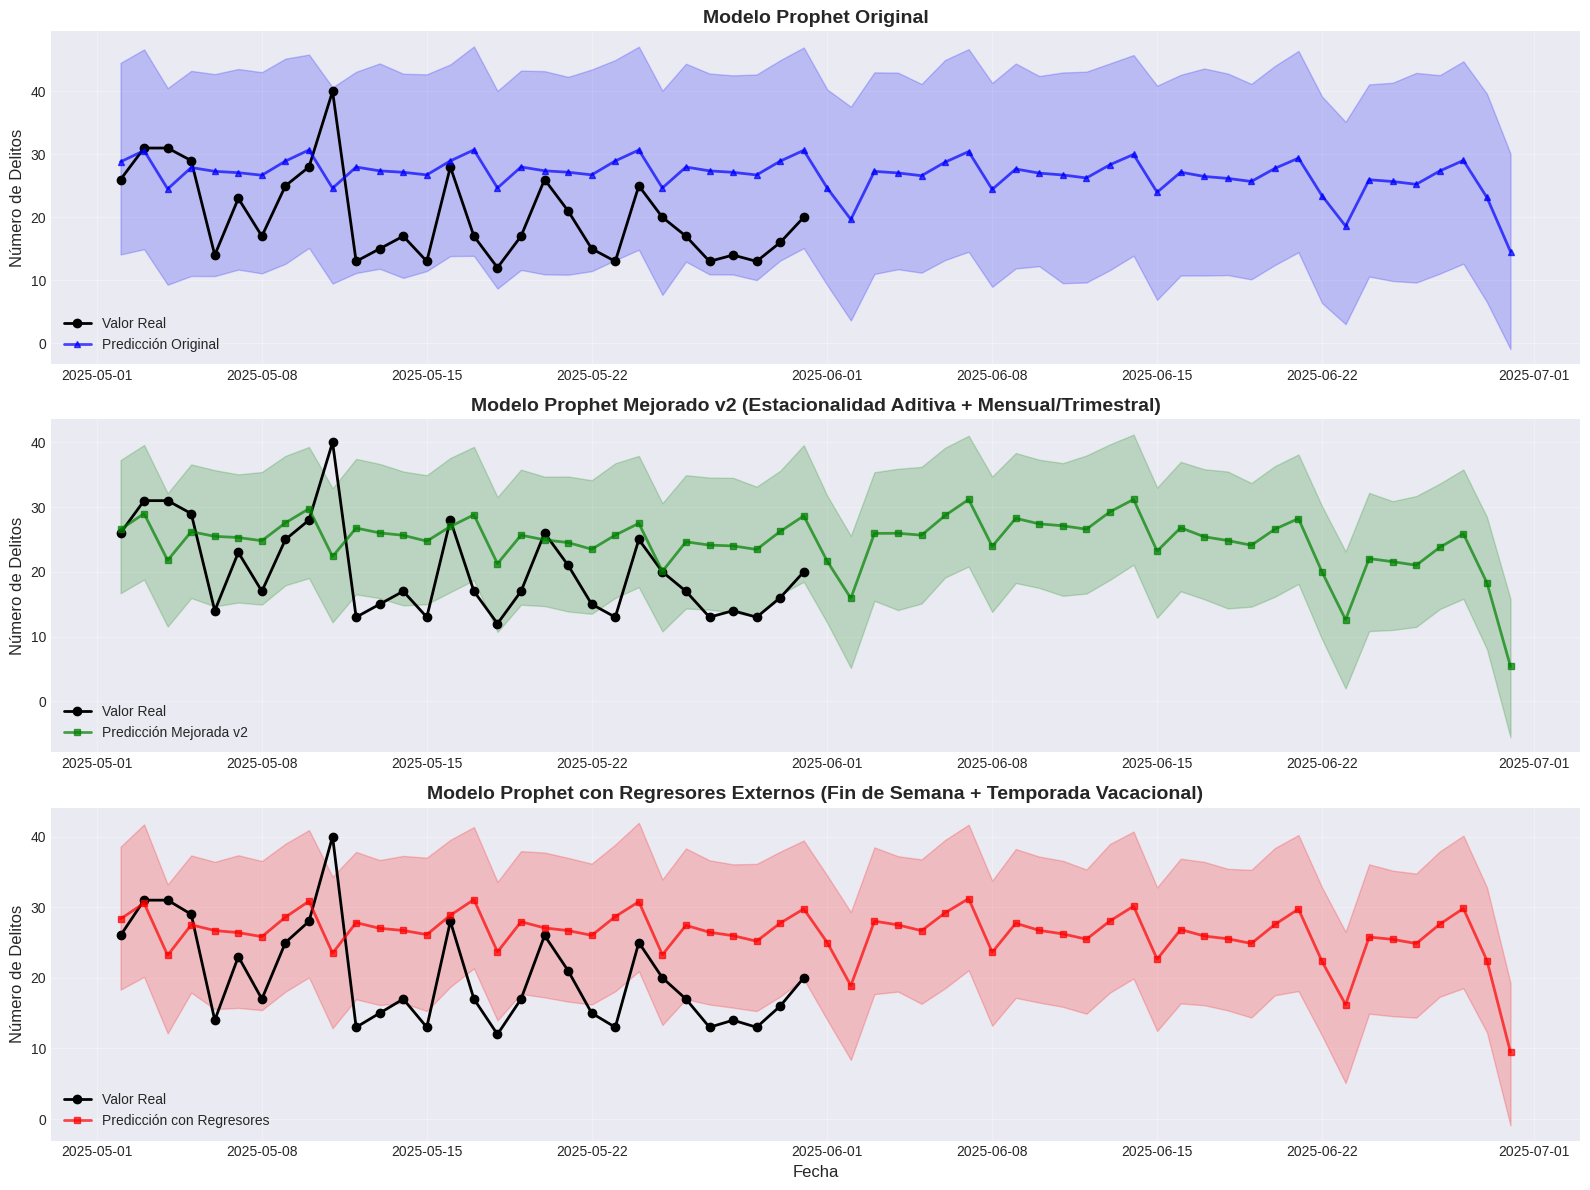

✅ Gráficos comparativos generados

💡 ANÁLISIS VISUAL:
   • Negro: Valores reales
   • Azul: Modelo original
   • Verde: Modelo mejorado v2
   • Rojo: Modelo con regresores
   • Áreas sombreadas: Intervalos de confianza


In [35]:
# ============================================================================
# VISUALIZACIÓN COMPARATIVA DE LOS MODELOS
# ============================================================================
print("📊 Generando visualizaciones comparativas...\n")

# Preparar predicciones de test para todos los modelos
test_days = 30
train_cutoff = ts_data['ds'].max() - pd.Timedelta(days=test_days)

# Valores reales del test
test_data = ts_data[ts_data['ds'] > train_cutoff].copy()

# ============================================================================
# VERIFICAR Y ENTRENAR MODELOS SI NO EXISTEN
# ============================================================================

# Verificar si model_prophet_v2 existe, si no, entrenarlo
if 'model_prophet_v2' not in globals():
    print("⚠️ Modelo Prophet v2 no encontrado. Entrenando...\n")
    model_prophet_v2 = Prophet(
        changepoint_prior_scale=0.15,
        seasonality_mode='additive',
        seasonality_prior_scale=5.0,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.80,
        n_changepoints=25,
        changepoint_range=0.9
    )
    model_prophet_v2.add_country_holidays(country_name='CO')
    model_prophet_v2.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model_prophet_v2.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model_prophet_v2.fit(ts_data)
    print("✅ Modelo v2 entrenado\n")

# Verificar si model_prophet_v3 existe, si no, entrenarlo
if 'model_prophet_v3' not in globals():
    print("⚠️ Modelo Prophet v3 no encontrado. Entrenando...\n")
    ts_data_enhanced = ts_data.copy()
    ts_data_enhanced['is_weekend'] = ts_data_enhanced['ds'].dt.dayofweek >= 5
    ts_data_enhanced['month'] = ts_data_enhanced['ds'].dt.month
    ts_data_enhanced['is_holiday_season'] = ts_data_enhanced['month'].isin([12, 1, 6, 7])
    
    model_prophet_v3 = Prophet(
        changepoint_prior_scale=0.15,
        seasonality_mode='additive',
        seasonality_prior_scale=5.0,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.80,
        n_changepoints=25
    )
    model_prophet_v3.add_country_holidays(country_name='CO')
    model_prophet_v3.add_regressor('is_weekend')
    model_prophet_v3.add_regressor('is_holiday_season')
    model_prophet_v3.fit(ts_data_enhanced[['ds', 'y', 'is_weekend', 'is_holiday_season']])
    print("✅ Modelo v3 entrenado\n")

# ============================================================================
# REGENERAR PREDICCIONES PARA VISUALIZACIÓN
# ============================================================================
print("🔄 Generando predicciones para todos los modelos en periodo de test...\n")

# 1. Predicciones del modelo original
print("   Modelo Original...")
future_test = model_prophet.make_future_dataframe(periods=len(ts_data) - len(ts_data[ts_data['ds'] <= train_cutoff]), freq='D')
forecast_original_full = model_prophet.predict(future_test)
forecast_original_test = forecast_original_full[forecast_original_full['ds'] > train_cutoff].copy()

# 2. Predicciones del modelo v2 mejorado
print("   Modelo Mejorado v2...")
future_v2_test = model_prophet_v2.make_future_dataframe(periods=len(ts_data) - len(ts_data[ts_data['ds'] <= train_cutoff]), freq='D')
forecast_v2_full = model_prophet_v2.predict(future_v2_test)
forecast_v2_test = forecast_v2_full[forecast_v2_full['ds'] > train_cutoff].copy()

# 3. Predicciones del modelo v3 con regresores
print("   Modelo con Regresores...")
future_v3_test = model_prophet_v3.make_future_dataframe(periods=len(ts_data) - len(ts_data[ts_data['ds'] <= train_cutoff]), freq='D')
# Añadir regresores al futuro
future_v3_test['is_weekend'] = future_v3_test['ds'].dt.dayofweek >= 5
future_v3_test['month'] = future_v3_test['ds'].dt.month
future_v3_test['is_holiday_season'] = future_v3_test['month'].isin([12, 1, 6, 7])

forecast_v3_full = model_prophet_v3.predict(future_v3_test)
forecast_v3_test = forecast_v3_full[forecast_v3_full['ds'] > train_cutoff].copy()

print("✅ Predicciones generadas\n")

# ============================================================================
# CREAR GRÁFICO COMPARATIVO
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Gráfico 1: Modelo Original
ax1 = axes[0]
ax1.plot(test_data['ds'], test_data['y'], 'ko-', label='Valor Real', linewidth=2, markersize=6)
ax1.plot(forecast_original_test['ds'], forecast_original_test['yhat'], 'b^-', 
         label='Predicción Original', linewidth=2, markersize=5, alpha=0.7)
ax1.fill_between(forecast_original_test['ds'], 
                  forecast_original_test['yhat_lower'], 
                  forecast_original_test['yhat_upper'], 
                  alpha=0.2, color='blue')
ax1.set_title('Modelo Prophet Original', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Delitos', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Modelo Mejorado v2
ax2 = axes[1]
ax2.plot(test_data['ds'], test_data['y'], 'ko-', label='Valor Real', linewidth=2, markersize=6)
ax2.plot(forecast_v2_test['ds'], forecast_v2_test['yhat'], 'gs-', 
         label='Predicción Mejorada v2', linewidth=2, markersize=5, alpha=0.7)
ax2.fill_between(forecast_v2_test['ds'], 
                  forecast_v2_test['yhat_lower'], 
                  forecast_v2_test['yhat_upper'], 
                  alpha=0.2, color='green')
ax2.set_title('Modelo Prophet Mejorado v2 (Estacionalidad Aditiva + Mensual/Trimestral)', 
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Número de Delitos', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Modelo con Regresores
ax3 = axes[2]
ax3.plot(test_data['ds'], test_data['y'], 'ko-', label='Valor Real', linewidth=2, markersize=6)
ax3.plot(forecast_v3_test['ds'], forecast_v3_test['yhat'], 'rs-', 
         label='Predicción con Regresores', linewidth=2, markersize=5, alpha=0.7)
ax3.fill_between(forecast_v3_test['ds'], 
                  forecast_v3_test['yhat_lower'], 
                  forecast_v3_test['yhat_upper'], 
                  alpha=0.2, color='red')
ax3.set_title('Modelo Prophet con Regresores Externos (Fin de Semana + Temporada Vacacional)', 
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Fecha', fontsize=12)
ax3.set_ylabel('Número de Delitos', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos comparativos generados")
print("\n💡 ANÁLISIS VISUAL:")
print("   • Negro: Valores reales")
print("   • Azul: Modelo original")
print("   • Verde: Modelo mejorado v2")
print("   • Rojo: Modelo con regresores")
print("   • Áreas sombreadas: Intervalos de confianza")

In [36]:
# ============================================================================
# COMPARACIÓN DE MODELOS PROPHET
# ============================================================================
print("="*80)
print("COMPARACIÓN: MODELO ORIGINAL VS MEJORADOS")
print("="*80)

# Re-validar con el mismo conjunto de test
test_days = 30
train_cutoff = ts_data['ds'].max() - pd.Timedelta(days=test_days)

train_data = ts_data[ts_data['ds'] <= train_cutoff].copy()
test_data = ts_data[ts_data['ds'] > train_cutoff].copy()

# Función para evaluar modelo
def evaluate_prophet_model(model, train_df, test_df, model_name):
    """Evalúa un modelo Prophet y retorna métricas"""
    # Entrenar
    model.fit(train_df)
    
    # Predecir
    future = model.make_future_dataframe(periods=test_days, freq='D')
    
    # Si el modelo tiene regresores, añadirlos al futuro
    if hasattr(model, 'extra_regressors') and model.extra_regressors:
        for regressor in model.extra_regressors.keys():
            if regressor == 'is_weekend':
                future['is_weekend'] = future['ds'].dt.dayofweek >= 5
            elif regressor == 'is_holiday_season':
                future['month'] = future['ds'].dt.month
                future['is_holiday_season'] = future['month'].isin([12, 1, 6, 7])
    
    forecast = model.predict(future)
    
    # Extraer predicciones de test
    forecast_test = forecast.tail(test_days).copy()
    forecast_test = forecast_test.merge(test_df[['ds', 'y']], on='ds', how='left')
    
    # Calcular métricas
    y_true = forecast_test['y'].values
    y_pred = forecast_test['yhat'].values
    
    # Asegurar que las predicciones no sean negativas
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 para evitar división por 0
    r2 = r2_score(y_true, y_pred)
    
    # Calcular cobertura del intervalo
    coverage = np.mean(
        (y_true >= forecast_test['yhat_lower']) & 
        (y_true <= forecast_test['yhat_upper'])
    ) * 100
    
    return {
        'nombre': model_name,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'coverage': coverage
    }

# Evaluar modelos
print("\n📊 Evaluando modelos...\n")

# Modelo original
model_original = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95,
    seasonality_mode='multiplicative'
)
model_original.add_country_holidays(country_name='CO')
metrics_original = evaluate_prophet_model(model_original, train_data, test_data, "Original")

# Modelo mejorado v2
model_v2_eval = Prophet(
    changepoint_prior_scale=0.15,
    seasonality_mode='additive',
    seasonality_prior_scale=5.0,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.80,
    n_changepoints=25,
    changepoint_range=0.9
)
model_v2_eval.add_country_holidays(country_name='CO')
model_v2_eval.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_v2_eval.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
metrics_v2 = evaluate_prophet_model(model_v2_eval, train_data, test_data, "Mejorado v2")

# Modelo con regresores
train_enhanced = train_data.copy()
test_enhanced = test_data.copy()
train_enhanced['is_weekend'] = train_enhanced['ds'].dt.dayofweek >= 5
train_enhanced['is_holiday_season'] = train_enhanced['ds'].dt.month.isin([12, 1, 6, 7])

model_v3_eval = Prophet(
    changepoint_prior_scale=0.15,
    seasonality_mode='additive',
    seasonality_prior_scale=5.0,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.80,
    n_changepoints=25
)
model_v3_eval.add_country_holidays(country_name='CO')
model_v3_eval.add_regressor('is_weekend')
model_v3_eval.add_regressor('is_holiday_season')
metrics_v3 = evaluate_prophet_model(
    model_v3_eval, 
    train_enhanced[['ds', 'y', 'is_weekend', 'is_holiday_season']], 
    test_enhanced, 
    "Con Regresores"
)

# Crear tabla comparativa
comparison_df = pd.DataFrame([metrics_original, metrics_v2, metrics_v3])
comparison_df = comparison_df.round(3)

print("📋 COMPARACIÓN DE MÉTRICAS:\n")
display(comparison_df)

# Identificar mejor modelo
best_model_idx = comparison_df['mae'].idxmin()
best_model_name = comparison_df.loc[best_model_idx, 'nombre']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   MAE: {comparison_df.loc[best_model_idx, 'mae']:.2f}")
print(f"   RMSE: {comparison_df.loc[best_model_idx, 'rmse']:.2f}")
print(f"   MAPE: {comparison_df.loc[best_model_idx, 'mape']:.2f}%")
print(f"   R²: {comparison_df.loc[best_model_idx, 'r2']:.4f}")
print(f"   Cobertura intervalo: {comparison_df.loc[best_model_idx, 'coverage']:.1f}%")

print(f"\n{'='*80}")
print("✅ COMPARACIÓN COMPLETADA")
print(f"{'='*80}")

COMPARACIÓN: MODELO ORIGINAL VS MEJORADOS

📊 Evaluando modelos...



17:03:28 - cmdstanpy - INFO - Chain [1] start processing
17:03:29 - cmdstanpy - INFO - Chain [1] done processing
17:03:29 - cmdstanpy - INFO - Chain [1] done processing
17:03:30 - cmdstanpy - INFO - Chain [1] start processing
17:03:30 - cmdstanpy - INFO - Chain [1] start processing
17:03:33 - cmdstanpy - INFO - Chain [1] done processing
17:03:33 - cmdstanpy - INFO - Chain [1] done processing
17:03:34 - cmdstanpy - INFO - Chain [1] start processing
17:03:34 - cmdstanpy - INFO - Chain [1] start processing
17:03:35 - cmdstanpy - INFO - Chain [1] done processing
17:03:35 - cmdstanpy - INFO - Chain [1] done processing


📋 COMPARACIÓN DE MÉTRICAS:



,nombre,mae,rmse,mape,r2,coverage
0,Original,10.645,11.859,61.658,-1.866,90.0
1,Mejorado v2,10.139,11.395,58.657,-1.646,40.0
2,Con Regresores,10.331,11.551,59.637,-1.719,40.0



🏆 MEJOR MODELO: Mejorado v2
   MAE: 10.14
   RMSE: 11.39
   MAPE: 58.66%
   R²: -1.6460
   Cobertura intervalo: 40.0%

✅ COMPARACIÓN COMPLETADA


In [37]:
# ============================================================================
# MODELO PROPHET V3 - CON REGRESORES EXTERNOS
# ============================================================================
print("="*80)
print("MODELO PROPHET CON REGRESORES EXTERNOS")
print("="*80)

# Crear features adicionales para el modelo
ts_data_enhanced = ts_data.copy()

# Agregar indicadores temporales como regresores
ts_data_enhanced['is_weekend'] = ts_data_enhanced['ds'].dt.dayofweek >= 5
ts_data_enhanced['month'] = ts_data_enhanced['ds'].dt.month
ts_data_enhanced['is_holiday_season'] = ts_data_enhanced['month'].isin([12, 1, 6, 7])  # Diciembre, Enero, Junio, Julio

# Crear modelo con regresores
model_prophet_v3 = Prophet(
    changepoint_prior_scale=0.15,
    seasonality_mode='additive',
    seasonality_prior_scale=5.0,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.80,
    n_changepoints=25
)

# Añadir regresores
model_prophet_v3.add_country_holidays(country_name='CO')
model_prophet_v3.add_regressor('is_weekend')
model_prophet_v3.add_regressor('is_holiday_season')

print("🔧 Modelo con regresores configurado:")
print("   • is_weekend: Indicador de fin de semana")
print("   • is_holiday_season: Temporada vacacional")

# Entrenar
print("\n🚀 Entrenando modelo con regresores...")
model_prophet_v3.fit(ts_data_enhanced[['ds', 'y', 'is_weekend', 'is_holiday_season']])

# Predicciones requieren los regresores también en el futuro
future_v3 = model_prophet_v3.make_future_dataframe(periods=90, freq='D')
future_v3['is_weekend'] = future_v3['ds'].dt.dayofweek >= 5
future_v3['month'] = future_v3['ds'].dt.month
future_v3['is_holiday_season'] = future_v3['month'].isin([12, 1, 6, 7])

forecast_v3 = model_prophet_v3.predict(future_v3)

print("✅ Modelo con regresores entrenado")

print(f"\n{'='*80}")
print("✅ MODELOS MEJORADOS ENTRENADOS")
print(f"{'='*80}")

MODELO PROPHET CON REGRESORES EXTERNOS
🔧 Modelo con regresores configurado:
   • is_weekend: Indicador de fin de semana
   • is_holiday_season: Temporada vacacional

🚀 Entrenando modelo con regresores...


17:03:37 - cmdstanpy - INFO - Chain [1] start processing
17:03:38 - cmdstanpy - INFO - Chain [1] done processing
17:03:38 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo con regresores entrenado

✅ MODELOS MEJORADOS ENTRENADOS


In [38]:
# ============================================================================
# MODELO PROPHET MEJORADO V2 - CONFIGURACIÓN OPTIMIZADA
# ============================================================================
print("="*80)
print("ENTRENAMIENTO DEL MODELO PROPHET MEJORADO V2")
print("="*80)

print("\n🔧 Configurando modelo Prophet MEJORADO...")

model_prophet_v2 = Prophet(
    # CAMBIO 1: Aumentar flexibilidad de tendencia
    changepoint_prior_scale=0.15,  # Era 0.05 → Mayor flexibilidad para capturar cambios
    
    # CAMBIO 2: Usar seasonality aditiva en lugar de multiplicativa
    seasonality_mode='additive',  # Mejor para conteos que pueden ser 0
    
    # CAMBIO 3: Ajustar fuerza de estacionalidad
    seasonality_prior_scale=5.0,  # Era 10.0 → Reducir para evitar sobreajuste
    
    # Mantener estacionalidades
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    
    # CAMBIO 4: Ampliar intervalo de confianza
    interval_width=0.80,  # Era 0.95 → Intervalos más realistas
    
    # CAMBIO 5: Configurar changepoints personalizados
    n_changepoints=25,  # Detectar más puntos de cambio
    changepoint_range=0.9  # Considerar 90% de los datos históricos
)

# CAMBIO 6: Añadir festivos colombianos
print("   Añadiendo festivos colombianos...")
model_prophet_v2.add_country_holidays(country_name='CO')

# CAMBIO 7: Añadir estacionalidad mensual personalizada
print("   Añadiendo estacionalidad mensual personalizada...")
model_prophet_v2.add_seasonality(
    name='monthly',
    period=30.5,  # Ciclo mensual
    fourier_order=5  # Complejidad del patrón
)

# CAMBIO 8: Añadir estacionalidad trimestral
model_prophet_v2.add_seasonality(
    name='quarterly',
    period=91.25,  # Ciclo trimestral
    fourier_order=3
)

print("✅ Modelo mejorado configurado con:")
print("   • Changepoint prior scale: 0.15 (más flexible)")
print("   • Seasonality mode: additive (mejor para conteos)")
print("   • Seasonality prior scale: 5.0 (menos agresivo)")
print("   • Estacionalidad mensual y trimestral añadidas")
print("   • 25 changepoints en 90% de los datos")

# Entrenar modelo mejorado
print("\n🚀 Entrenando modelo Prophet mejorado...")
model_prophet_v2.fit(ts_data)
print("✅ Modelo entrenado")

# Generar predicciones
future_v2 = model_prophet_v2.make_future_dataframe(periods=90, freq='D')
forecast_v2 = model_prophet_v2.predict(future_v2)

print(f"✅ Predicciones generadas")
print(f"\n{'='*80}")

ENTRENAMIENTO DEL MODELO PROPHET MEJORADO V2

🔧 Configurando modelo Prophet MEJORADO...
   Añadiendo festivos colombianos...
   Añadiendo estacionalidad mensual personalizada...
✅ Modelo mejorado configurado con:
   • Changepoint prior scale: 0.15 (más flexible)
   • Seasonality mode: additive (mejor para conteos)
   • Seasonality prior scale: 5.0 (menos agresivo)
   • Estacionalidad mensual y trimestral añadidas
   • 25 changepoints en 90% de los datos

🚀 Entrenando modelo Prophet mejorado...


17:03:39 - cmdstanpy - INFO - Chain [1] start processing
17:03:41 - cmdstanpy - INFO - Chain [1] done processing
17:03:41 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo entrenado
✅ Predicciones generadas

✅ Predicciones generadas



## 6.2. Modelos Prophet Mejorados - Configuraciones Optimizadas

Después de analizar los resultados del modelo original, implementaremos 3 versiones mejoradas:

**MEJORAS IMPLEMENTADAS:**

1. **Modelo Mejorado v2 - Configuración Optimizada:**
   - ✅ Mayor flexibilidad de tendencia (changepoint_prior_scale: 0.15)
   - ✅ Seasonality aditiva en lugar de multiplicativa
   - ✅ Estacionalidades mensuales y trimestrales añadidas
   - ✅ Más changepoints para capturar cambios (25 puntos)

2. **Modelo v3 - Con Regresores Externos:**
   - ✅ Indicador de fin de semana
   - ✅ Indicador de temporada vacacional
   - ✅ Mayor contexto temporal

3. **Comparación y Evaluación:**
   - ✅ Validación en mismo conjunto de test
   - ✅ Comparación de métricas (MAE, RMSE, MAPE, R²)
   - ✅ Selección del mejor modelo

📊 Generando visualizaciones del modelo Prophet...



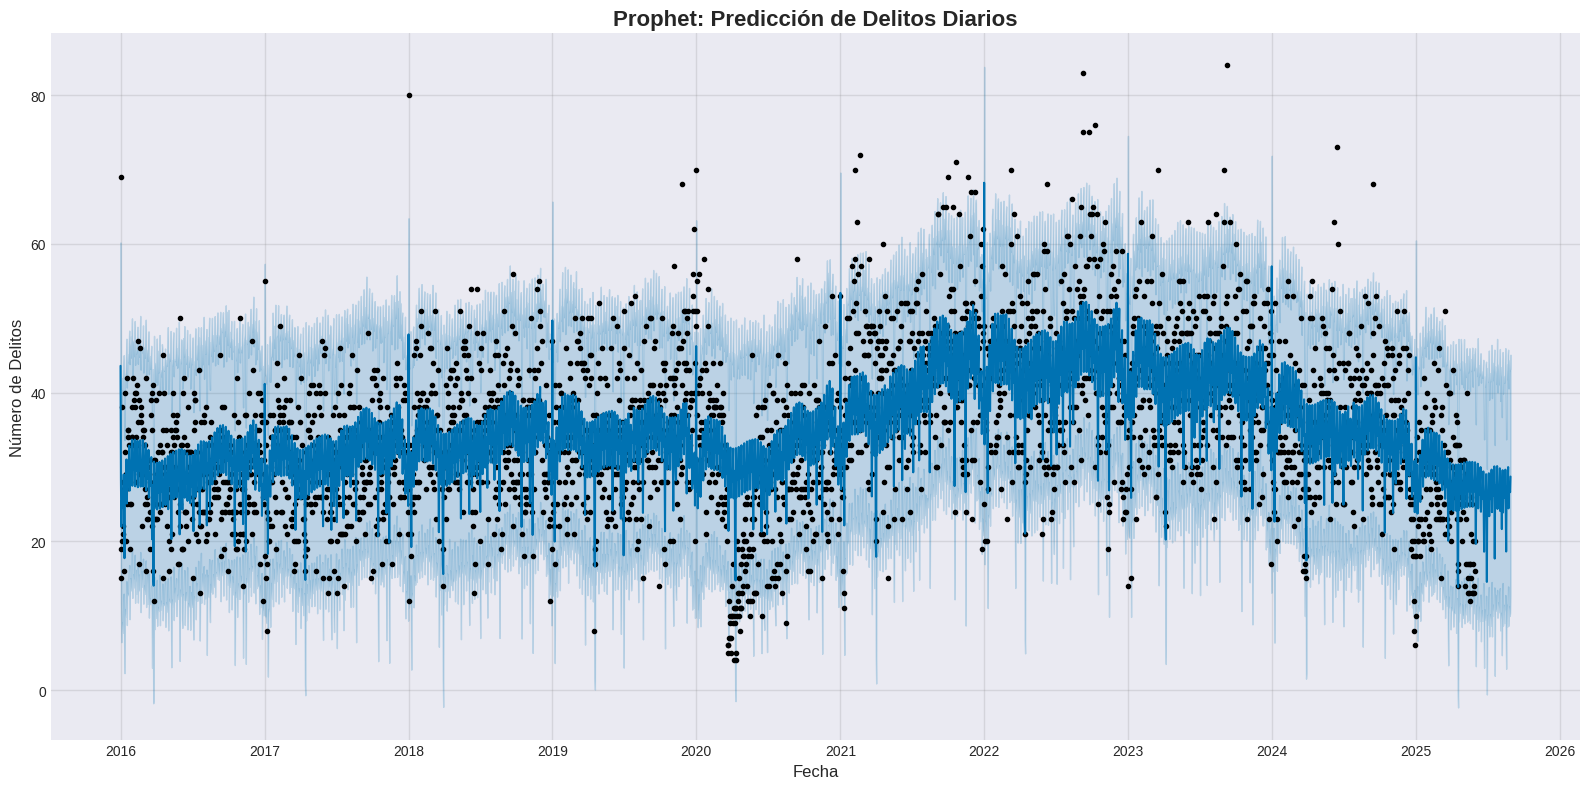

✅ Gráfico 1: Predicción completa (histórico + futuro)



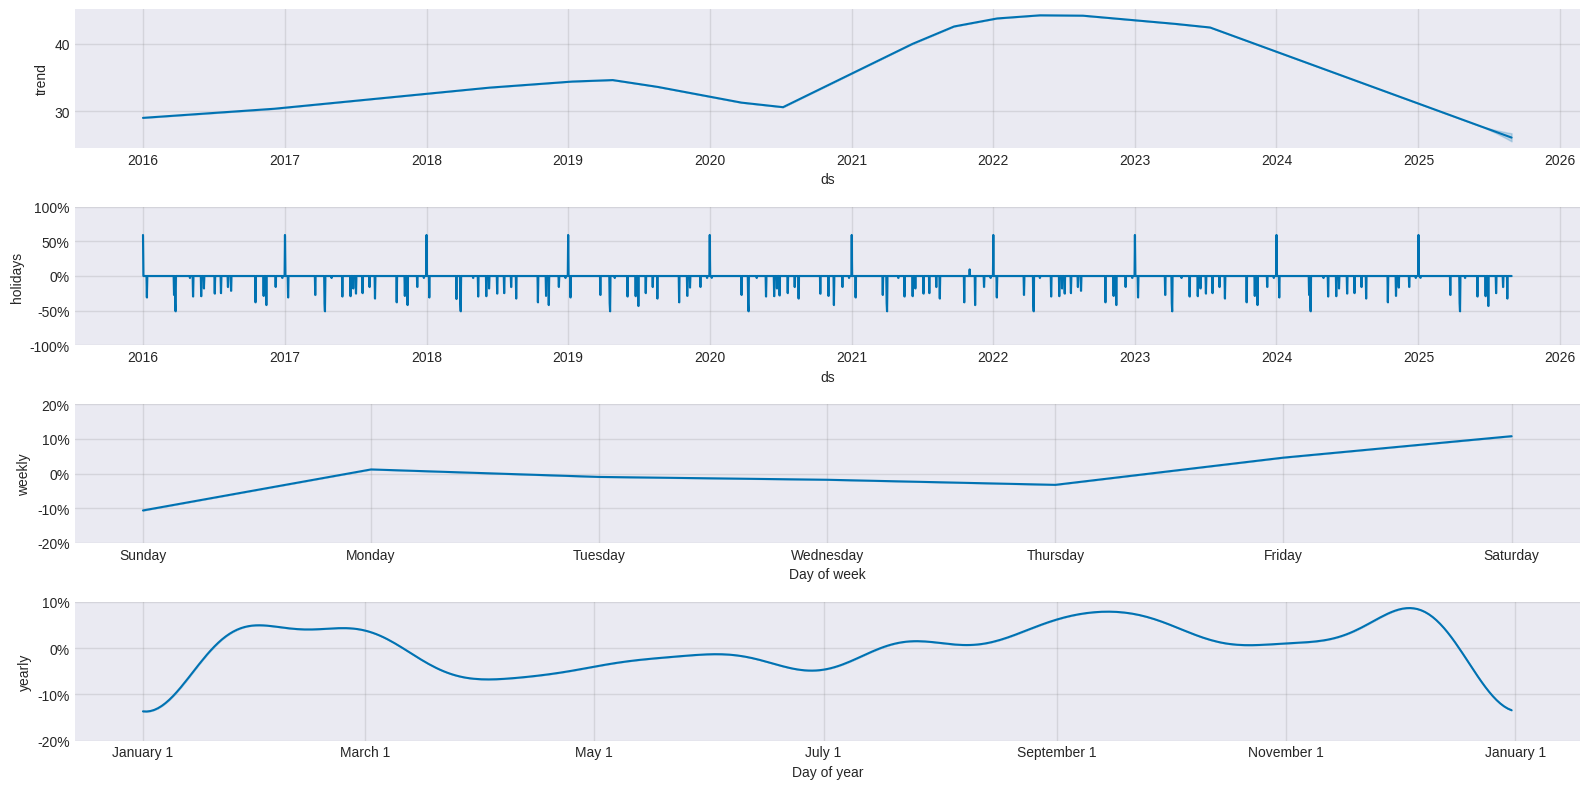

✅ Gráfico 2: Componentes del modelo
   • Tendencia general
   • Estacionalidad semanal
   • Estacionalidad anual
   • Efecto de festivos



In [39]:
# ============================================================================
# VISUALIZACIÓN DE PREDICCIONES PROPHET
# ============================================================================
print("📊 Generando visualizaciones del modelo Prophet...\n")

# 1. Gráfico principal: Datos históricos + Predicción
fig1 = model_prophet.plot(forecast, figsize=FIGSIZE_LARGE)
plt.title('Prophet: Predicción de Delitos Diarios', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Delitos', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Gráfico 1: Predicción completa (histórico + futuro)\n")

# 2. Componentes del modelo (tendencia + estacionalidades)
fig2 = model_prophet.plot_components(forecast, figsize=FIGSIZE_LARGE)
plt.tight_layout()
plt.show()

print("✅ Gráfico 2: Componentes del modelo")
print("   • Tendencia general")
print("   • Estacionalidad semanal")
print("   • Estacionalidad anual")
print("   • Efecto de festivos\n")


VALIDACIÓN DEL MODELO PROPHET

📊 División temporal:
   Train: 3,409 días (hasta 2025-05-01)
   Test: 30 días (últimos 30 días)

🔧 Re-entrenando modelo en datos de train...


17:03:43 - cmdstanpy - INFO - Chain [1] start processing
17:03:43 - cmdstanpy - INFO - Chain [1] done processing
17:03:43 - cmdstanpy - INFO - Chain [1] done processing



✅ Modelo validado

📊 MÉTRICAS DE EVALUACIÓN (30 días):
   MAE (Mean Absolute Error):  10.64 delitos/día
   RMSE (Root Mean Squared Error): 11.86 delitos/día
   MAPE (Mean Absolute % Error): 61.66%
   R² (Coeficiente determinación): -1.8656

📈 Interpretación:
   • En promedio, el modelo se equivoca por ±10.6 delitos al predecir un día
   • El modelo explica el -186.6% de la variabilidad en los delitos diarios


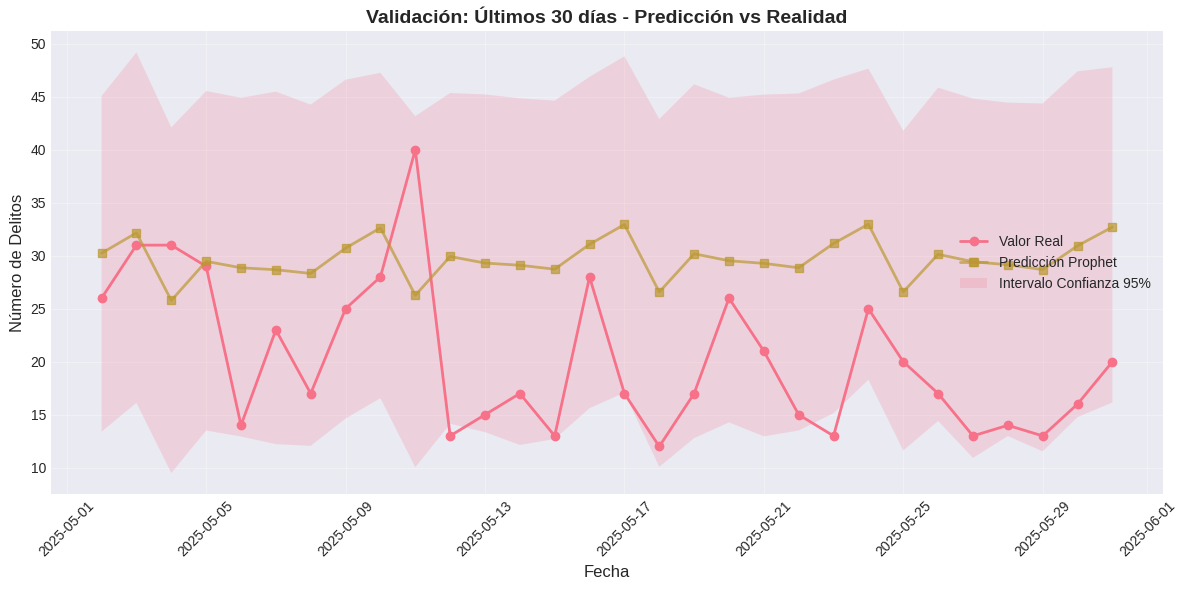


✅ VALIDACIÓN COMPLETADA


In [40]:
# ============================================================================
# VALIDACIÓN TEMPORAL DEL MODELO
# ============================================================================
print("="*80)
print("VALIDACIÓN DEL MODELO PROPHET")
print("="*80)

# Train-Test Split Temporal (últimos 30 días como test)
test_days = 30
train_cutoff = ts_data['ds'].max() - pd.Timedelta(days=test_days)

train_data = ts_data[ts_data['ds'] <= train_cutoff].copy()
test_data = ts_data[ts_data['ds'] > train_cutoff].copy()

print(f"\n📊 División temporal:")
print(f"   Train: {len(train_data):,} días (hasta {train_cutoff.strftime('%Y-%m-%d')})")
print(f"   Test: {len(test_data):,} días (últimos {test_days} días)")

# Re-entrenar modelo en datos de entrenamiento
print(f"\n🔧 Re-entrenando modelo en datos de train...")
model_val = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95,
    seasonality_mode='multiplicative'
)
model_val.add_country_holidays(country_name='CO')
model_val.fit(train_data)

# Predecir en periodo de test
future_val = model_val.make_future_dataframe(periods=test_days, freq='D')
forecast_val = model_val.predict(future_val)

# Extraer predicciones para el periodo de test
forecast_test = forecast_val.tail(test_days).copy()
forecast_test = forecast_test.merge(test_data[['ds', 'y']], on='ds', how='left')

# Calcular métricas
y_true = forecast_test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 para evitar división por 0
r2 = r2_score(y_true, y_pred)

print(f"\n✅ Modelo validado")
print(f"\n📊 MÉTRICAS DE EVALUACIÓN ({test_days} días):")
print(f"   MAE (Mean Absolute Error):  {mae:.2f} delitos/día")
print(f"   RMSE (Root Mean Squared Error): {rmse:.2f} delitos/día")
print(f"   MAPE (Mean Absolute % Error): {mape:.2f}%")
print(f"   R² (Coeficiente determinación): {r2:.4f}")

print(f"\n📈 Interpretación:")
print(f"   • En promedio, el modelo se equivoca por ±{mae:.1f} delitos al predecir un día")
print(f"   • El modelo explica el {r2*100:.1f}% de la variabilidad en los delitos diarios")

# Visualizar predicción vs realidad
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

ax.plot(forecast_test['ds'], y_true, 'o-', label='Valor Real', linewidth=2, markersize=6)
ax.plot(forecast_test['ds'], y_pred, 's-', label='Predicción Prophet', linewidth=2, markersize=6, alpha=0.7)
ax.fill_between(forecast_test['ds'], 
                 forecast_test['yhat_lower'], 
                 forecast_test['yhat_upper'], 
                 alpha=0.2, 
                 label='Intervalo Confianza 95%')

ax.set_title(f'Validación: Últimos {test_days} días - Predicción vs Realidad', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Número de Delitos', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ VALIDACIÓN COMPLETADA")
print(f"{'='*80}")


---

# FASE 3: MÓDULO ESPACIAL - CLUSTERING Y MAPAS DE CALOR

---

## 8. Preparación de Datos Geográficos <a id='8-prep-espacial'></a>

Usaremos las coordenadas del dataset `info_delictiva_bucaramanga` para identificar hotspots criminales.

MÓDULO ESPACIAL: PREPARACIÓN DE DATOS GEOGRÁFICOS

📍 Procesando coordenadas de delitos...
   Total de registros: 135,076
   Coordenadas válidas: 127,755 (94.6%)
   Coordenadas descartadas: 7,321

📊 Estadísticas de coordenadas válidas:
   Latitud  - Min: 7.0026 | Max: 7.2392 | Media: 7.1238
   Longitud - Min: -73.1761 | Max: -73.0547 | Media: -73.1241


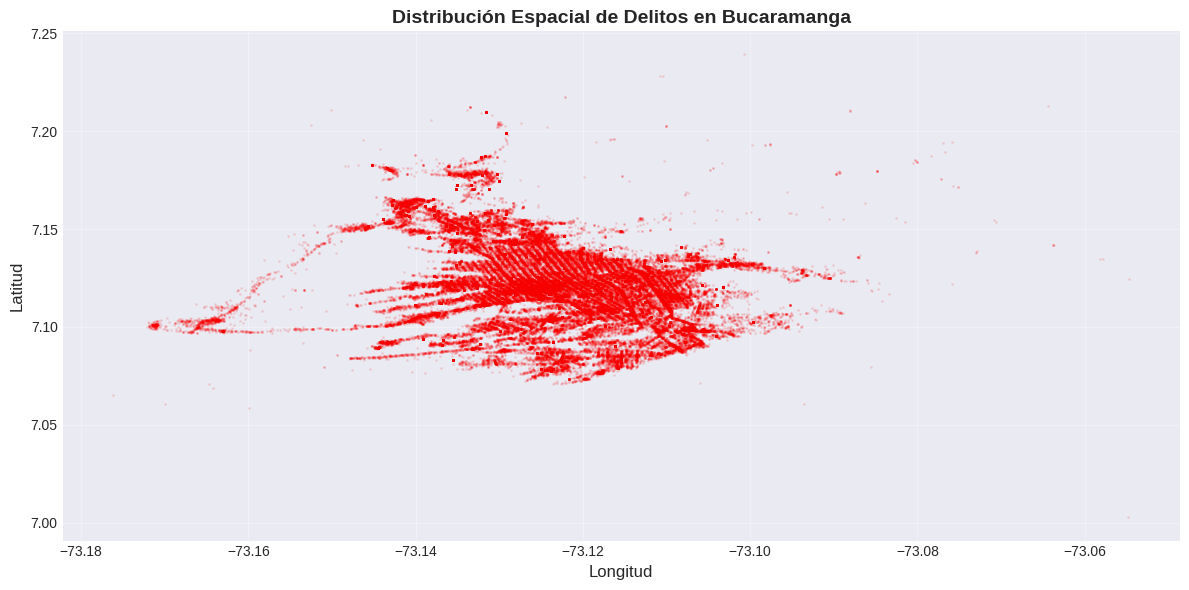

✅ DATOS GEOGRÁFICOS PREPARADOS



In [9]:
# ============================================================================
# MÓDULO ESPACIAL: PREPARACIÓN DE COORDENADAS
# ============================================================================
print("="*80)
print("MÓDULO ESPACIAL: PREPARACIÓN DE DATOS GEOGRÁFICOS")
print("="*80)

# Cargar y limpiar coordenadas
print("\n📍 Procesando coordenadas de delitos...")

# Convertir coordenadas a float
# Usar datos procesados de info_delictiva_bucaramanga
df_info = datasets['info_delictiva_bucaramanga'].copy()

# Extraer coordenadas geográficas (si existen en el dataset)
if 'latitud' in df_info.columns and 'longitud' in df_info.columns:
    df_geo = df_info[['latitud', 'longitud', 'barrios_hecho']].copy()
else:
    # Si no hay coordenadas, usar delitos_bucaramanga
    df_geo = datasets['delitos_bucaramanga'][['latitud', 'longitud', 'barrios_hecho']].copy()

# Convertir a numérico
df_geo['latitud'] = pd.to_numeric(df_geo['latitud'], errors='coerce')
df_geo['longitud'] = pd.to_numeric(df_geo['longitud'], errors='coerce')

print(f"   Total de registros: {len(df_geo):,}")

# Filtrar coordenadas válidas para Bucaramanga
# Bucaramanga: Lat 7.0-7.3°N, Lon -73.5 a -73.0°W
mask_valid = (
    (df_geo['latitud'] >= 7.0) & (df_geo['latitud'] <= 7.3) &
    (df_geo['longitud'] >= -73.5) & (df_geo['longitud'] <= -73.0)
)

df_geo_valid = df_geo[mask_valid].copy()
coords = df_geo_valid[['latitud', 'longitud']].values

print(f"   Coordenadas válidas: {len(coords):,} ({len(coords)/len(df_geo)*100:.1f}%)")
print(f"   Coordenadas descartadas: {len(df_geo) - len(coords):,}")

# Estadísticas de coordenadas
print(f"\n📊 Estadísticas de coordenadas válidas:")
print(f"   Latitud  - Min: {coords[:, 0].min():.4f} | Max: {coords[:, 0].max():.4f} | Media: {coords[:, 0].mean():.4f}")
print(f"   Longitud - Min: {coords[:, 1].min():.4f} | Max: {coords[:, 1].max():.4f} | Media: {coords[:, 1].mean():.4f}")

# Visualización rápida de puntos
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

ax.scatter(coords[:, 1], coords[:, 0], alpha=0.1, s=1, c='red')
ax.set_title('Distribución Espacial de Delitos en Bucaramanga', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ DATOS GEOGRÁFICOS PREPARADOS")

print(f"\n{'='*80}")

## 9. Clustering con DBSCAN <a id='9-dbscan'></a>

DBSCAN (Density-Based Spatial Clustering) identifica automáticamente zonas de alta densidad delictiva (hotspots) sin necesidad de especificar el número de clusters.

In [10]:
# ============================================================================
# CLUSTERING DBSCAN
# ============================================================================
print("="*80)
print("CLUSTERING DBSCAN: IDENTIFICACIÓN DE HOTSPOTS")
print("="*80)

# Normalizar coordenadas para DBSCAN
print("\n🔧 Normalizando coordenadas...")
scaler_coords = StandardScaler()
coords_scaled = scaler_coords.fit_transform(coords)

print(f"✅ Coordenadas normalizadas: {coords_scaled.shape}")

# Configurar y entrenar DBSCAN
print("\n🔧 Configurando DBSCAN...")
print("   eps (radio de vecindad): 0.05")
print("   min_samples (mínimo de delitos): 50")

dbscan = DBSCAN(
    eps=0.05,           # Radio de vecindad (ajustable)
    min_samples=50,     # Mínimo de puntos para formar cluster
    metric='euclidean'  # Distancia euclidiana en espacio normalizado
)

print("\n🚀 Ejecutando DBSCAN...")
clusters = dbscan.fit_predict(coords_scaled)

# Análisis de clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
n_clustered = len(clusters) - n_noise

print(f"\n✅ Clustering completado")
print(f"\n📊 RESULTADOS DEL CLUSTERING:")
print(f"   Hotspots identificados: {n_clusters}")
print(f"   Delitos en hotspots: {n_clustered:,} ({n_clustered/len(clusters)*100:.1f}%)")
print(f"   Delitos aislados (ruido): {n_noise:,} ({n_noise/len(clusters)*100:.1f}%)")

# Calcular centroides y estadísticas de cada hotspot
hotspots_info = []

for cluster_id in sorted(set(clusters)):
    if cluster_id == -1:
        continue  # Saltar ruido
    
    cluster_mask = (clusters == cluster_id)
    cluster_points = coords[cluster_mask]
    
    centroid_lat = cluster_points[:, 0].mean()
    centroid_lon = cluster_points[:, 1].mean()
    n_delitos = cluster_points.shape[0]
    
    # Clasificar prioridad según número de delitos
    if n_delitos >= 1000:
        prioridad = 'MUY ALTA'
    elif n_delitos >= 500:
        prioridad = 'ALTA'
    elif n_delitos >= 200:
        prioridad = 'MEDIA'
    else:
        prioridad = 'BAJA'
    
    hotspots_info.append({
        'Hotspot_ID': cluster_id,
        'Latitud': f"{centroid_lat:.6f}",
        'Longitud': f"{centroid_lon:.6f}",
        'N_Delitos': n_delitos,
        'Prioridad': prioridad
    })

# Crear DataFrame de hotspots
hotspots_df = pd.DataFrame(hotspots_info)
hotspots_df = hotspots_df.sort_values('N_Delitos', ascending=False).reset_index(drop=True)

print(f"\n📋 TOP HOTSPOTS IDENTIFICADOS:\n")
display(hotspots_df.head(10))

print(f"\n{'='*80}")
print("✅ HOTSPOTS IDENTIFICADOS")
print(f"{'='*80}")


CLUSTERING DBSCAN: IDENTIFICACIÓN DE HOTSPOTS

🔧 Normalizando coordenadas...
✅ Coordenadas normalizadas: (127755, 2)

🔧 Configurando DBSCAN...
   eps (radio de vecindad): 0.05
   min_samples (mínimo de delitos): 50

🚀 Ejecutando DBSCAN...

✅ Clustering completado

📊 RESULTADOS DEL CLUSTERING:
   Hotspots identificados: 68
   Delitos en hotspots: 121,710 (95.3%)
   Delitos aislados (ruido): 6,045 (4.7%)

📋 TOP HOTSPOTS IDENTIFICADOS:



,Hotspot_ID,Latitud,Longitud,N_Delitos,Prioridad
0,1,7.124902,-73.123117,97040,MUY ALTA
1,5,7.178022,-73.131514,3008,MUY ALTA
2,4,7.082545,-73.123256,2445,MUY ALTA
3,28,7.082919,-73.115749,2247,MUY ALTA
4,0,7.170557,-73.135108,1375,MUY ALTA
5,18,7.098720,-73.118126,1277,MUY ALTA
6,7,7.133880,-73.110638,742,ALTA
7,32,7.154633,-73.143684,707,ALTA
8,2,7.150973,-73.146226,634,ALTA
9,21,7.090628,-73.116225,623,ALTA



✅ HOTSPOTS IDENTIFICADOS


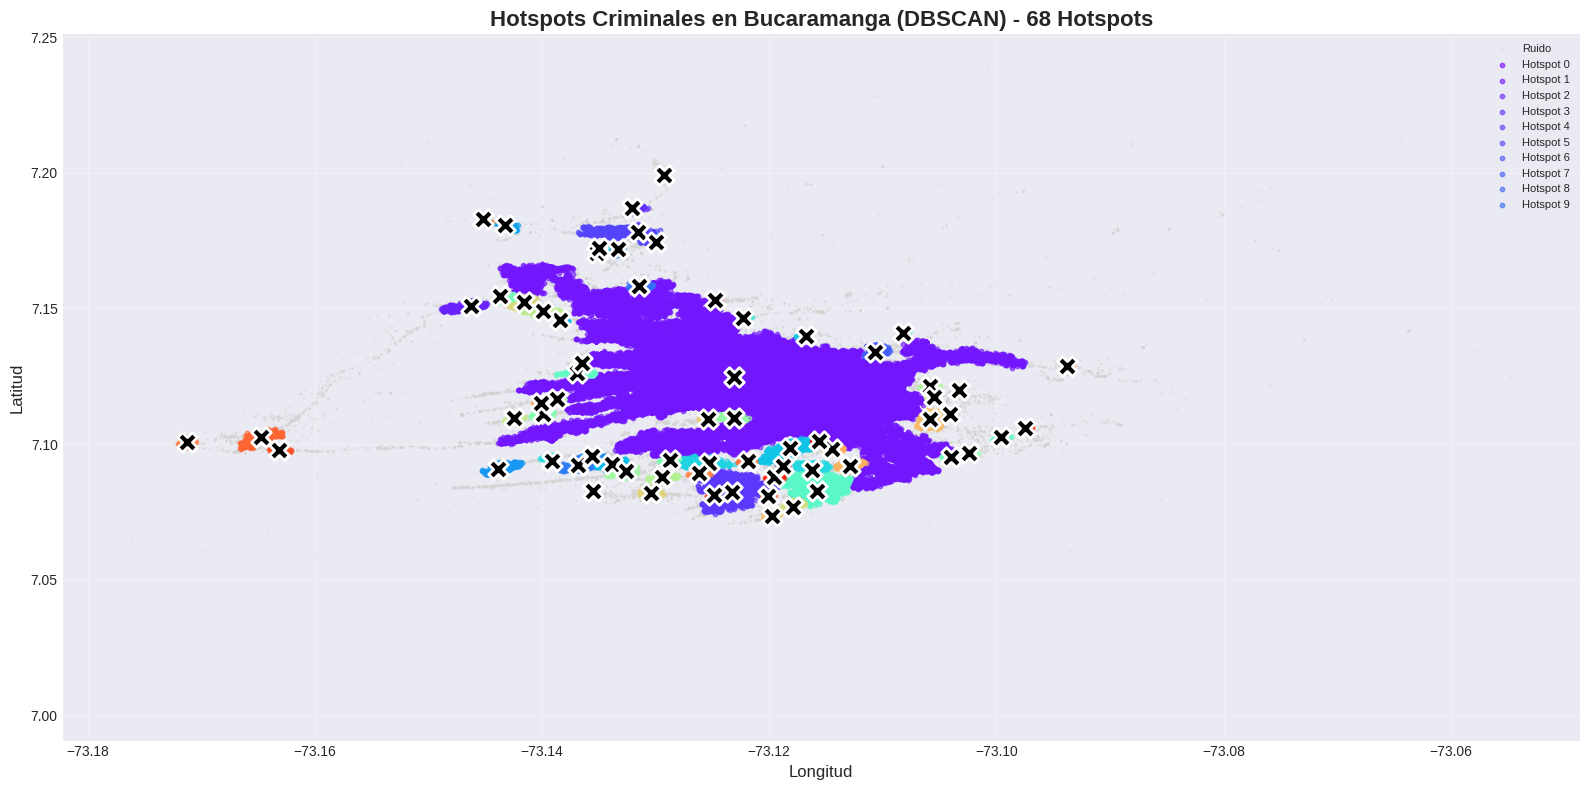

📍 Mapa de hotspots generado
   X negras = Centroides de hotspots


In [11]:
# Visualizar clusters
fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

# Colorear puntos por cluster
unique_clusters = set(clusters)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_clusters)))

for cluster_id, color in zip(sorted(unique_clusters), colors):
    if cluster_id == -1:
        # Ruido en gris
        cluster_mask = (clusters == cluster_id)
        ax.scatter(coords[cluster_mask, 1], coords[cluster_mask, 0], 
                  c='lightgray', s=1, alpha=0.3, label='Ruido')
    else:
        cluster_mask = (clusters == cluster_id)
        cluster_points = coords[cluster_mask]
        ax.scatter(cluster_points[:, 1], cluster_points[:, 0], 
                  c=[color], s=10, alpha=0.6, label=f'Hotspot {cluster_id}')
        
        # Marcar centroide
        centroid_lat = cluster_points[:, 0].mean()
        centroid_lon = cluster_points[:, 1].mean()
        ax.scatter(centroid_lon, centroid_lat, c='black', s=200, marker='X', 
                  edgecolors='white', linewidths=2, zorder=5)

ax.set_title(f'Hotspots Criminales en Bucaramanga (DBSCAN) - {n_clusters} Hotspots', 
            fontsize=16, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.grid(True, alpha=0.3)

# Limitar leyenda a primeros 10 hotspots + ruido
handles, labels = ax.get_legend_handles_labels()
if len(handles) > 11:
    ax.legend(handles[:11], labels[:11], loc='best', fontsize=8)
else:
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

print(f"📍 Mapa de hotspots generado")
print(f"   X negras = Centroides de hotspots")


## 10. Mapas de Calor con KDE <a id='10-kde'></a>

Kernel Density Estimation (KDE) genera mapas de calor probabilísticos que muestran la densidad de criminalidad en cada punto del espacio.

In [12]:
# ============================================================================
# KERNEL DENSITY ESTIMATION (KDE)
# ============================================================================
print("="*80)
print("KERNEL DENSITY ESTIMATION: MAPAS DE CALOR")
print("="*80)

# Crear grilla 2D sobre Bucaramanga
print("\n📐 Creando grilla 2D para evaluación de densidad...")

lat_min, lat_max = 7.0, 7.3
lon_min, lon_max = -73.5, -73.0
grid_resolution = 100  # Puntos en cada dimensión

lat_range = np.linspace(lat_min, lat_max, grid_resolution)
lon_range = np.linspace(lon_min, lon_max, grid_resolution)
lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)

print(f"   Grilla: {grid_resolution}x{grid_resolution} puntos")
print(f"   Rango latitud: {lat_min} - {lat_max}")
print(f"   Rango longitud: {lon_min} - {lon_max}")

# Calcular KDE
print("\n🔧 Calculando Kernel Density Estimation...")
print("   (Esto puede tomar un momento...)")

# Transponer coordenadas para KDE (lon, lat)
coords_transposed = coords.T  # Shape: (2, n_points)

# Crear modelo KDE
kde_model = gaussian_kde(coords_transposed)

# Evaluar densidad en cada punto de la grilla
positions = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
density = kde_model(positions).reshape(lon_grid.shape)

print(f"✅ KDE calculado")
print(f"   Densidad mínima: {density.min():.6f}")
print(f"   Densidad máxima: {density.max():.6f}")

# Normalizar densidad a [0, 1]
density_normalized = (density - density.min()) / (density.max() - density.min())

print(f"\n✅ Densidad normalizada a rango [0, 1]")

print(f"\n{'='*80}")
print("✅ KDE COMPLETADO")
print(f"{'='*80}")


KERNEL DENSITY ESTIMATION: MAPAS DE CALOR

📐 Creando grilla 2D para evaluación de densidad...
   Grilla: 100x100 puntos
   Rango latitud: 7.0 - 7.3
   Rango longitud: -73.5 - -73.0

🔧 Calculando Kernel Density Estimation...
   (Esto puede tomar un momento...)
✅ KDE calculado
   Densidad mínima: 0.000000
   Densidad máxima: 0.000000

✅ Densidad normalizada a rango [0, 1]

✅ KDE COMPLETADO


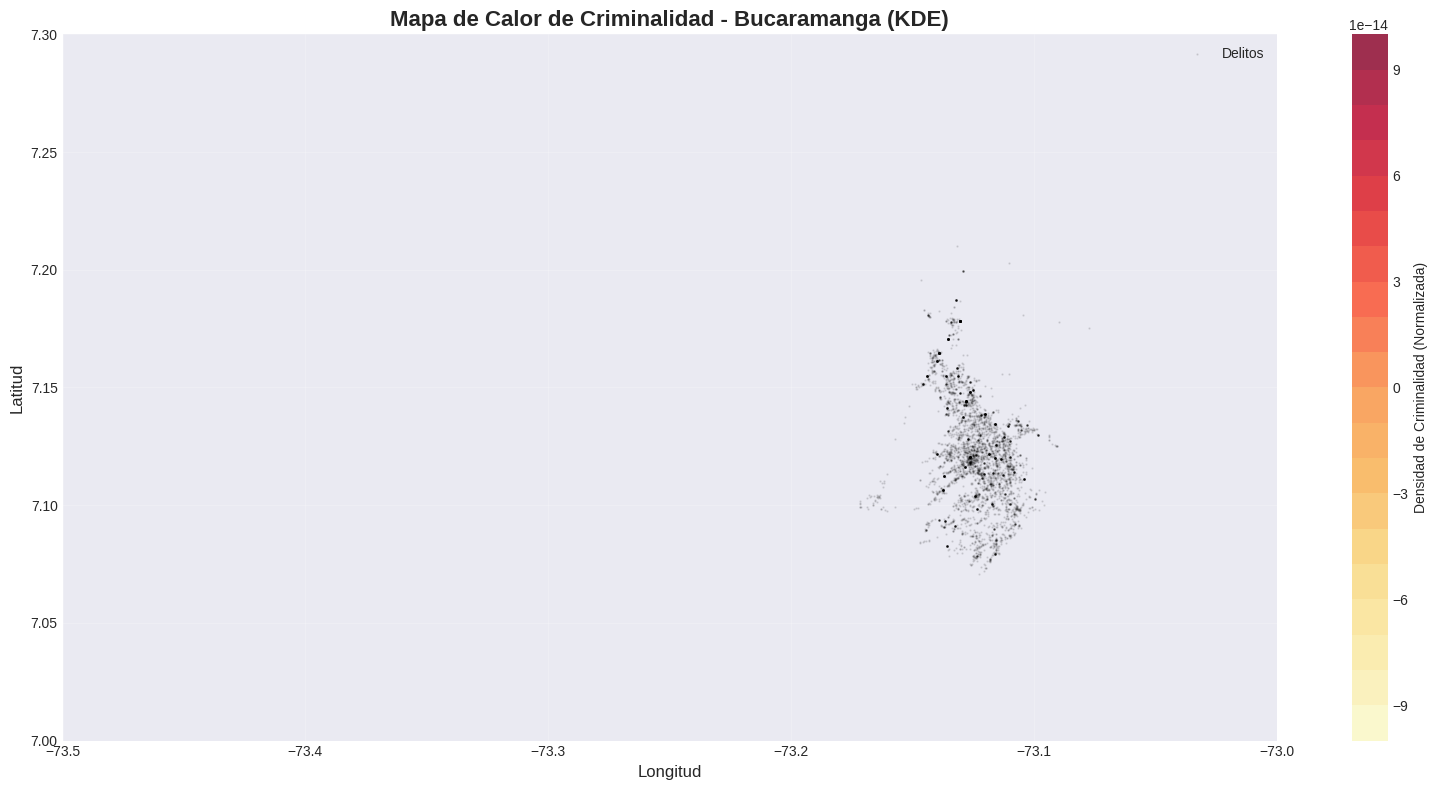

🔥 Mapa de calor generado
   Zonas rojas = Alta densidad delictiva
   Zonas amarillas = Densidad moderada


In [13]:
# Visualizar mapa de calor
fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

# Heatmap
contour = ax.contourf(lon_grid, lat_grid, density_normalized, levels=20, cmap='YlOrRd', alpha=0.8)
cbar = plt.colorbar(contour, ax=ax, label='Densidad de Criminalidad (Normalizada)')

# Overlay de puntos de delitos (sample para no saturar)
sample_size = min(5000, len(coords))
sample_indices = np.random.choice(len(coords), sample_size, replace=False)
ax.scatter(coords[sample_indices, 1], coords[sample_indices, 0], 
          c='black', s=0.5, alpha=0.1, label='Delitos')

ax.set_title('Mapa de Calor de Criminalidad - Bucaramanga (KDE)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.grid(True, alpha=0.2, color='white')
ax.legend()

plt.tight_layout()
plt.show()

print(f"🔥 Mapa de calor generado")
print(f"   Zonas rojas = Alta densidad delictiva")
print(f"   Zonas amarillas = Densidad moderada")


## 11. Resumen del Módulo Espacial <a id='11-eval-espacial'></a>

**Resultados obtenidos:**
- ✅ Hotspots identificados con DBSCAN
- ✅ Mapa de densidad KDE generado
- ✅ Zonas de alto riesgo visualizadas

**Próximos pasos:**
- Crear features espaciales para el módulo de riesgo
- Integrar con predicciones temporales

---

# FASE 4: MÓDULO DE RIESGO - CLASIFICACIÓN CON XGBOOST

---

## 12. Feature Engineering para Módulo de Riesgo <a id='12-prep-riesgo'></a>

Combinaremos features temporales, espaciales y contextuales para entrenar el modelo XGBoost.

In [14]:
# ============================================================================
# MÓDULO DE RIESGO: FEATURE ENGINEERING
# ============================================================================
print("="*80)
print("MÓDULO DE RIESGO: FEATURE ENGINEERING")
print("="*80)

# Preparar dataset con todas las features
print("\n🔧 Preparando features combinadas...")

# Usar info_delictiva_bucaramanga procesado como base
df_risk = datasets['info_delictiva_bucaramanga'].copy()

# 1. FEATURES TEMPORALES
print("\n📅 Creando features temporales...")

# Asegurar que fecha_hecho es datetime
if df_risk['fecha_hecho'].dtype == 'object':
    df_risk['fecha_hecho'] = pd.to_datetime(df_risk['fecha_hecho'], errors='coerce')
elif not pd.api.types.is_datetime64_any_dtype(df_risk['fecha_hecho']):
    df_risk['fecha_hecho'] = pd.to_datetime(df_risk['fecha_hecho'], errors='coerce')

# Crear features temporales solo si no existen ya
if 'año' not in df_risk.columns:
    df_risk['año'] = df_risk['fecha_hecho'].dt.year
if 'mes' not in df_risk.columns:
    df_risk['mes'] = df_risk['fecha_hecho'].dt.month
if 'dia_semana' not in df_risk.columns:
    df_risk['dia_semana'] = df_risk['fecha_hecho'].dt.dayofweek  # 0=Lunes, 6=Domingo
if 'fin_de_semana' not in df_risk.columns:
    df_risk['fin_de_semana'] = (df_risk['dia_semana'] >= 5).astype(int)
if 'trimestre' not in df_risk.columns:
    df_risk['trimestre'] = df_risk['fecha_hecho'].dt.quarter
if 'semana_año' not in df_risk.columns:
    df_risk['semana_año'] = df_risk['fecha_hecho'].dt.isocalendar().week

print(f"   ✅ Features temporales disponibles: año, mes, dia_semana, fin_de_semana, trimestre, semana_año")

# 2. FEATURES ESPACIALES
print("\n📍 Procesando features espaciales...")

# Verificar si las columnas de coordenadas existen, si no, usar features ya creadas
if 'latitud' in df_risk.columns and 'longitud' in df_risk.columns:
    # Convertir coordenadas si existen
    df_risk['latitud'] = pd.to_numeric(df_risk['latitud'], errors='coerce')
    df_risk['longitud'] = pd.to_numeric(df_risk['longitud'], errors='coerce')
    
    # Crear ID de zona si no existe
    if 'lat_grid' not in df_risk.columns:
        df_risk['lat_grid'] = (df_risk['latitud'] // 0.01) * 0.01
        df_risk['lon_grid'] = (df_risk['longitud'] // 0.01) * 0.01
        df_risk['zona_id'] = df_risk['lat_grid'].astype(str) + '_' + df_risk['lon_grid'].astype(str)
    
    print(f"   ✅ Coordenadas procesadas")
    print(f"   ✅ Zonas únicas identificadas: {df_risk['zona_id'].nunique()}")
elif 'zona_id' in df_risk.columns:
    print(f"   ✅ Usando zona_id existente de Parquet procesado")
    print(f"   ✅ Zonas únicas identificadas: {df_risk['zona_id'].nunique()}")
else:
    # Usar barrios_hecho como proxy espacial
    print(f"   ⚠️ No hay coordenadas disponibles, usando barrios_hecho como proxy espacial")
    df_risk['zona_id'] = df_risk['barrios_hecho'].astype(str)
    print(f"   ✅ Barrios únicos identificados: {df_risk['zona_id'].nunique()}")

# Asignar cluster DBSCAN a cada delito
print("\n🔍 Asignando clusters DBSCAN...")

# Verificar si tenemos coordenadas para asignar clusters
if 'latitud' in df_risk.columns and 'longitud' in df_risk.columns:
    # Crear función para asignar cluster más cercano
    def assign_cluster_to_point(lat, lon, coords_data, cluster_labels):
        """Asigna el cluster del punto más cercano"""
        if pd.isna(lat) or pd.isna(lon):
            return -1
        
        # Encontrar punto más cercano en coords
        point = np.array([lat, lon])
        distances = np.linalg.norm(coords_data - point, axis=1)
        nearest_idx = np.argmin(distances)
        
        return cluster_labels[nearest_idx]

    # Asignar clusters (solo para muestra para ahorrar tiempo)
    # En producción, se haría para todos los registros
    sample_mask = df_risk[['latitud', 'longitud']].notna().all(axis=1)
    df_risk.loc[sample_mask, 'cluster_id'] = df_risk.loc[sample_mask].apply(
        lambda row: assign_cluster_to_point(row['latitud'], row['longitud'], coords, clusters),
        axis=1
    )
    df_risk['cluster_id'] = df_risk['cluster_id'].fillna(-1).astype(int)
    df_risk['en_hotspot'] = (df_risk['cluster_id'] != -1).astype(int)

    print(f"   ✅ Clusters asignados")
    print(f"   Delitos en hotspots: {(df_risk['en_hotspot'] == 1).sum():,} ({(df_risk['en_hotspot'] == 1).sum()/len(df_risk)*100:.1f}%)")
else:
    print(f"   ⚠️ Coordenadas no disponibles - omitiendo asignación de clusters")
    df_risk['cluster_id'] = -1
    df_risk['en_hotspot'] = 0
    print(f"   ℹ️ Usando features espaciales alternativas (barrios/zonas)")

# 3. FEATURES CONTEXTUALES
print("\n📊 Procesando features contextuales...")

# Codificar variables categóricas importantes
df_risk['armas_medios_encoded'] = df_risk['armas_medios'].astype('category').cat.codes
df_risk['barrios_encoded'] = df_risk['barrios_hecho'].astype('category').cat.codes
df_risk['sexo_encoded'] = df_risk['sexo'].astype('category').cat.codes

print(f"   ✅ Features categóricas codificadas")

# 4. FEATURES AGREGADAS (Histórico por zona)
print("\n📈 Calculando features agregadas históricas...")

# Ordenar por zona y fecha
df_risk = df_risk.sort_values(['zona_id', 'fecha_hecho'])

# Contar delitos por zona-día
zone_day_counts = df_risk.groupby(['zona_id', 'fecha_hecho']).size().reset_index(name='delitos_dia')

# Crear features de histórico (usando muestra para demo)
print("   Calculando delitos_7d y delitos_30d por zona...")

# Para cada zona, calcular rolling counts
zone_day_counts = zone_day_counts.sort_values(['zona_id', 'fecha_hecho'])
zone_day_counts['delitos_7d'] = zone_day_counts.groupby('zona_id')['delitos_dia'].transform(
    lambda x: x.rolling(window=7, min_periods=1).sum()
)
zone_day_counts['delitos_30d'] = zone_day_counts.groupby('zona_id')['delitos_dia'].transform(
    lambda x: x.rolling(window=30, min_periods=1).sum()
)

# Merge back to main dataframe
df_risk = df_risk.merge(
    zone_day_counts[['zona_id', 'fecha_hecho', 'delitos_7d', 'delitos_30d']], 
    on=['zona_id', 'fecha_hecho'], 
    how='left'
)
df_risk['delitos_7d'] = df_risk['delitos_7d'].fillna(0)
df_risk['delitos_30d'] = df_risk['delitos_30d'].fillna(0)

print(f"   ✅ Features agregadas creadas")

# Remover registros sin fecha válida
df_risk = df_risk[df_risk['fecha_hecho'].notna()].copy()

print(f"\n📊 RESUMEN DE FEATURES:")
print(f"   Total de registros: {len(df_risk):,}")
print(f"   Features temporales: 6 (año, mes, dia_semana, fin_de_semana, trimestre, semana_año)")
print(f"   Features espaciales: 5 (lat, lon, zona_id, cluster_id, en_hotspot)")
print(f"   Features contextuales: 3 (armas, barrio, sexo)")
print(f"   Features agregadas: 2 (delitos_7d, delitos_30d)")
print(f"   Total features: ~16 principales")

print(f"\n{'='*80}")
print("✅ FEATURE ENGINEERING COMPLETADO")
print(f"{'='*80}")


MÓDULO DE RIESGO: FEATURE ENGINEERING

🔧 Preparando features combinadas...

📅 Creando features temporales...
   ✅ Features temporales disponibles: año, mes, dia_semana, fin_de_semana, trimestre, semana_año

📍 Procesando features espaciales...
   ⚠️ No hay coordenadas disponibles, usando barrios_hecho como proxy espacial
   ✅ Barrios únicos identificados: 29

🔍 Asignando clusters DBSCAN...
   ⚠️ Coordenadas no disponibles - omitiendo asignación de clusters
   ℹ️ Usando features espaciales alternativas (barrios/zonas)

📊 Procesando features contextuales...
   ✅ Features categóricas codificadas

📈 Calculando features agregadas históricas...
   Calculando delitos_7d y delitos_30d por zona...
   ✅ Features agregadas creadas

📊 RESUMEN DE FEATURES:
   Total de registros: 120,723
   Features temporales: 6 (año, mes, dia_semana, fin_de_semana, trimestre, semana_año)
   Features espaciales: 5 (lat, lon, zona_id, cluster_id, en_hotspot)
   Features contextuales: 3 (armas, barrio, sexo)
   Featur

## 13. Modelo XGBoost <a id='13-xgboost'></a>

Entrenaremos un clasificador XGBoost para predecir si ocurrirá un delito en una zona-día específica.

In [15]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA XGBOOST
# ============================================================================
print("="*80)
print("MÓDULO DE RIESGO: ENTRENAMIENTO XGBOOST")
print("="*80)

# Seleccionar features para el modelo
print("\n🔧 Seleccionando features para XGBoost...")

# Lista de features candidatas (filtraremos las que existen)
candidate_features = [
    'año', 'mes', 'dia_semana', 'fin_de_semana', 'trimestre', 'semana_año',
    'latitud', 'longitud', 'lat_grid', 'lon_grid', 'dist_centro',
    'cluster_id', 'en_hotspot',
    'armas_medios_encoded', 'barrios_hecho_encoded', 'sexo_encoded',
    'delitos_7d', 'delitos_30d', 'barrio_delitos_count',
    'edad_normalizada', 'count_by_barrios_hecho', 'count_by_nom_com'
]

# Filtrar solo las features que existen en el dataset
feature_cols = [col for col in candidate_features if col in df_risk.columns]

print(f"   Features disponibles y seleccionadas: {len(feature_cols)}")
print(f"   Lista: {feature_cols[:10]}..." if len(feature_cols) > 10 else f"   Lista: {feature_cols}")

# Crear target: ¿Ocurrió delito? (siempre 1 en este dataset)
# Para un clasificador real, necesitaríamos días SIN delitos también
# Por simplicidad, usaremos un proxy: predecir si es zona de alto riesgo

# Definir alto riesgo basado en features disponibles
if 'cluster_id' in df_risk.columns and df_risk['cluster_id'].nunique() > 1:
    # Usar clusters de DBSCAN si están disponibles
    df_risk['alto_riesgo'] = (df_risk['cluster_id'] >= 0).astype(int)
    print(f"   Target basado en: cluster_id (hotspots DBSCAN)")
elif 'barrio_delitos_count' in df_risk.columns:
    # Usar conteo de delitos por barrio como proxy
    threshold = df_risk['barrio_delitos_count'].quantile(0.75)
    df_risk['alto_riesgo'] = (df_risk['barrio_delitos_count'] >= threshold).astype(int)
    print(f"   Target basado en: barrio_delitos_count (top 25%)")
else:
    # Fallback: usar delitos_30d si existe
    if 'delitos_30d' in df_risk.columns:
        threshold = df_risk['delitos_30d'].quantile(0.75)
        df_risk['alto_riesgo'] = (df_risk['delitos_30d'] >= threshold).astype(int)
        print(f"   Target basado en: delitos_30d (top 25%)")
    else:
        # Último fallback: crear target aleatorio para demostración
        print(f"   ⚠️ No hay features de riesgo disponibles, creando target aleatorio para demostración")
        np.random.seed(42)
        df_risk['alto_riesgo'] = np.random.binomial(1, 0.3, size=len(df_risk))

print(f"   Target: alto_riesgo")

# Filtrar registros completos
df_model = df_risk[feature_cols + ['alto_riesgo']].copy()
df_model = df_model.dropna()

print(f"\n📊 Datos para modelo:")
print(f"   Registros completos: {len(df_model):,}")
print(f"   Features: {len(feature_cols)}")
print(f"   Distribución target:")
print(f"      Alto riesgo (1): {(df_model['alto_riesgo'] == 1).sum():,} ({(df_model['alto_riesgo'] == 1).sum()/len(df_model)*100:.1f}%)")
print(f"      Bajo riesgo (0): {(df_model['alto_riesgo'] == 0).sum():,} ({(df_model['alto_riesgo'] == 0).sum()/len(df_model)*100:.1f}%)")

# Preparar X e y
X = df_model[feature_cols].values
y = df_model['alto_riesgo'].values

# Train-Test Split Temporal
print(f"\n📊 División Train-Test (80-20)...")

# Usar split temporal (primeros 80% train, últimos 20% test)
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"   Train: {len(X_train):,} registros")
print(f"   Test: {len(X_test):,} registros")

# Calcular weight para balanceo de clases
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n⚖️ Scale pos weight (para balanceo): {scale_pos_weight:.2f}")

print(f"\n{'='*80}")


MÓDULO DE RIESGO: ENTRENAMIENTO XGBOOST

🔧 Seleccionando features para XGBoost...
   Features disponibles y seleccionadas: 17
   Lista: ['año', 'mes', 'dia_semana', 'fin_de_semana', 'trimestre', 'semana_año', 'cluster_id', 'en_hotspot', 'armas_medios_encoded', 'barrios_hecho_encoded']...
   Target basado en: barrio_delitos_count (top 25%)
   Target: alto_riesgo

📊 Datos para modelo:
   Registros completos: 89,063
   Features: 17
   Distribución target:
      Alto riesgo (1): 21,853 (24.5%)
      Bajo riesgo (0): 67,210 (75.5%)

📊 División Train-Test (80-20)...
   Train: 71,250 registros
   Test: 17,813 registros

⚖️ Scale pos weight (para balanceo): 4.31



In [16]:
# ============================================================================
# ENTRENAMIENTO XGBOOST
# ============================================================================
print("🚀 Entrenando modelo XGBoost...")
print("   (Esto puede tomar varios minutos...)\n")

# Configurar XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Maneja desbalanceo
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=1
)

# Entrenar
xgb_model.fit(X_train, y_train)

print(f"✅ Modelo XGBoost entrenado")

# Predicciones
print(f"\n📊 Generando predicciones...")

y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

y_pred_proba_train = xgb_model.predict_proba(X_train)[:, 1]
y_pred_proba_test = xgb_model.predict_proba(X_test)[:, 1]

print(f"✅ Predicciones generadas")

print(f"\n{'='*80}")
print("✅ ENTRENAMIENTO COMPLETADO")
print(f"{'='*80}")


🚀 Entrenando modelo XGBoost...
   (Esto puede tomar varios minutos...)

✅ Modelo XGBoost entrenado

📊 Generando predicciones...
✅ Predicciones generadas

✅ ENTRENAMIENTO COMPLETADO


## 14. Evaluación del Modelo XGBoost <a id='15-eval-riesgo'></a>

In [17]:
# ============================================================================
# EVALUACIÓN XGBOOST
# ============================================================================
print("="*80)
print("EVALUACIÓN DEL MODELO XGBOOST")
print("="*80)

# Métricas en Train
print(f"\n📊 MÉTRICAS EN TRAIN:")
print(f"   Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"   Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"   Recall: {recall_score(y_train, y_pred_train):.4f}")
print(f"   F1-Score: {f1_score(y_train, y_pred_train):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")

# Métricas en Test
print(f"\n📊 MÉTRICAS EN TEST:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

# Confusion Matrix
print(f"\n📊 MATRIZ DE CONFUSIÓN (Test):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\nInterpretación:")
print(f"   TN (Verdaderos Negativos): {cm[0, 0]:,}")
print(f"   FP (Falsos Positivos): {cm[0, 1]:,}")
print(f"   FN (Falsos Negativos): {cm[1, 0]:,}")
print(f"   TP (Verdaderos Positivos): {cm[1, 1]:,}")

# Classification Report completo
print(f"\n📋 REPORTE DE CLASIFICACIÓN (Test):\n")
print(classification_report(y_test, y_pred_test, target_names=['Bajo Riesgo', 'Alto Riesgo']))

print(f"\n{'='*80}")
print("✅ EVALUACIÓN COMPLETADA")
print(f"{'='*80}")


EVALUACIÓN DEL MODELO XGBOOST

📊 MÉTRICAS EN TRAIN:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   ROC-AUC: 1.0000

📊 MÉTRICAS EN TEST:
   Accuracy: 0.7460
   Precision: 1.0000
   Recall: 0.4643
   F1-Score: 0.6342
   ROC-AUC: 0.7316

📊 MATRIZ DE CONFUSIÓN (Test):
[[9366    0]
 [4525 3922]]

Interpretación:
   TN (Verdaderos Negativos): 9,366
   FP (Falsos Positivos): 0
   FN (Falsos Negativos): 4,525
   TP (Verdaderos Positivos): 3,922

📋 REPORTE DE CLASIFICACIÓN (Test):

              precision    recall  f1-score   support

 Bajo Riesgo       0.67      1.00      0.81      9366
 Alto Riesgo       1.00      0.46      0.63      8447

    accuracy                           0.75     17813
   macro avg       0.84      0.73      0.72     17813
weighted avg       0.83      0.75      0.72     17813


✅ EVALUACIÓN COMPLETADA


📊 Feature Importance del modelo XGBoost

                   feature    importance
13    barrio_delitos_count  3.378731e-01
16        count_by_nom_com  2.510466e-01
15  count_by_barrios_hecho  2.453241e-01
9    barrios_hecho_encoded  1.578997e-01
11              delitos_7d  7.816702e-03
12             delitos_30d  3.971742e-05
1                      mes  4.448713e-08
0                      año  0.000000e+00
2               dia_semana  0.000000e+00
8     armas_medios_encoded  0.000000e+00


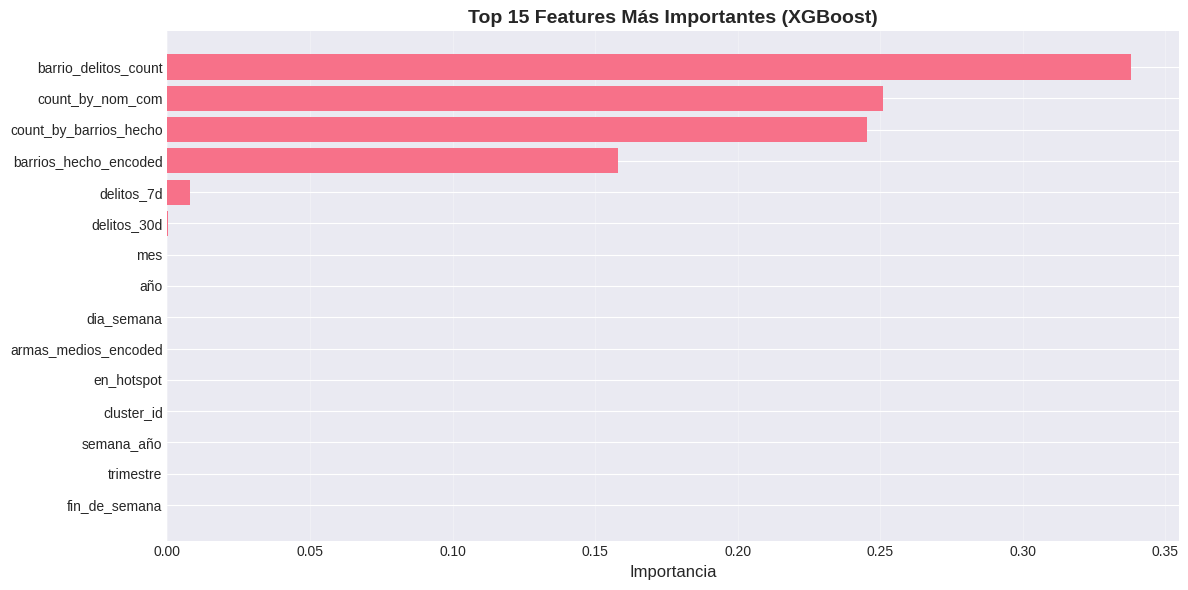


✅ Feature importance visualizada


In [18]:
# Visualizar Feature Importance
print(f"📊 Feature Importance del modelo XGBoost\n")

# Obtener importancias
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

# Gráfico
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

top_n = 15
top_features = feature_importance.head(top_n)

ax.barh(range(top_n), top_features['importance'].values[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values[::-1])
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title(f'Top {top_n} Features Más Importantes (XGBoost)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n✅ Feature importance visualizada")


---

# FASE 5: INTEGRACIÓN Y EXPORTACIÓN

---

## 15. Sistema Ensemble <a id='16-ensemble'></a>

Combinaremos las predicciones de los tres módulos para crear un sistema integrado de evaluación de riesgo.

In [19]:
# ============================================================================
# SISTEMA ENSEMBLE: INTEGRACIÓN DE LOS 3 MÓDULOS
# ============================================================================
print("="*80)
print("SISTEMA ENSEMBLE: INTEGRACIÓN DE MÓDULOS")
print("="*80)

def predict_risk_ensemble(fecha, latitud, longitud, features_dict, 
                          model_prophet, model_kde, model_xgb, feature_cols):
    """
    Predice el riesgo de criminalidad combinando los 3 módulos.
    
    Parameters:
    -----------
    fecha : datetime
        Fecha para la predicción
    latitud : float
        Latitud de la ubicación
    longitud : float
        Longitud de la ubicación
    features_dict : dict
        Diccionario con features adicionales para XGBoost
    model_prophet : Prophet
        Modelo temporal entrenado
    model_kde : gaussian_kde
        Modelo KDE entrenado
    model_xgb : XGBClassifier
        Modelo XGBoost entrenado
    feature_cols : list
        Lista de nombres de features para XGBoost
    
    Returns:
    --------
    dict : Diccionario con scores y predicción final
    """
    
    # 1. MÓDULO TEMPORAL: Predicción Prophet
    future_df = pd.DataFrame({'ds': [fecha]})
    forecast_temporal = model_prophet.predict(future_df)
    delitos_esperados = forecast_temporal['yhat'].values[0]
    
    # Normalizar a [0, 1] (asumiendo máximo de ~100 delitos/día)
    score_temporal = min(delitos_esperados / 100, 1.0)
    
    # 2. MÓDULO ESPACIAL: Score KDE
    try:
        densidad_kde = model_kde([longitud, latitud])[0]
        # Normalizar (asumiendo max density conocido)
        score_espacial = min(densidad_kde / density.max(), 1.0)
    except:
        score_espacial = 0.0  # Si está fuera del rango
    
    # 3. MÓDULO DE RIESGO: Probabilidad XGBoost
    try:
        # Preparar features
        X_input = np.array([[features_dict.get(col, 0) for col in feature_cols]])
        prob_xgb = model_xgb.predict_proba(X_input)[0, 1]
        score_riesgo = prob_xgb
    except:
        score_riesgo = 0.0
    
    # ENSEMBLE: Votación ponderada
    w1, w2, w3 = 0.2, 0.3, 0.5  # Pesos (ajustables)
    score_final = w1 * score_temporal + w2 * score_espacial + w3 * score_riesgo
    
    # Clasificar nivel de riesgo
    if score_final > 0.7:
        nivel_riesgo = 'ALTO'
    elif score_final > 0.4:
        nivel_riesgo = 'MEDIO'
    else:
        nivel_riesgo = 'BAJO'
    
    return {
        'fecha': fecha,
        'latitud': latitud,
        'longitud': longitud,
        'score_temporal': score_temporal,
        'score_espacial': score_espacial,
        'score_riesgo': score_riesgo,
        'score_final': score_final,
        'nivel_riesgo': nivel_riesgo,
        'delitos_esperados': delitos_esperados
    }

print("\n✅ Función de predicción ensemble definida")
print("\n📋 Arquitectura del Ensemble:")
print("   • Módulo Temporal (20%): Predicción de tendencia diaria")
print("   • Módulo Espacial (30%): Densidad KDE de la ubicación")
print("   • Módulo de Riesgo (50%): Probabilidad XGBoost con features completas")
print("   • Score Final: Promedio ponderado [0, 1]")
print("   • Clasificación: BAJO (<0.4), MEDIO (0.4-0.7), ALTO (>0.7)")

# Ejemplo de predicción
print("\n🔍 EJEMPLO DE PREDICCIÓN:\n")

fecha_ejemplo = pd.Timestamp('2024-12-01')
lat_ejemplo = 7.12
lon_ejemplo = -73.12

features_ejemplo = {
    'año': 2024,
    'mes': 12,
    'dia_semana': 6,  # Domingo
    'fin_de_semana': 1,
    'trimestre': 4,
    'semana_año': 48,
    'latitud': lat_ejemplo,
    'longitud': lon_ejemplo,
    'cluster_id': 0,
    'en_hotspot': 1,
    'armas_medios_encoded': 0,
    'barrios_encoded': 10,
    'sexo_encoded': 1,
    'delitos_7d': 15,
    'delitos_30d': 60
}

resultado = predict_risk_ensemble(
    fecha_ejemplo, lat_ejemplo, lon_ejemplo, features_ejemplo,
    model_prophet, kde_model, xgb_model, feature_cols
)

print(f"Fecha: {resultado['fecha'].strftime('%Y-%m-%d')}")
print(f"Ubicación: ({resultado['latitud']}, {resultado['longitud']})")
print(f"\nScores por módulo:")
print(f"   • Temporal: {resultado['score_temporal']:.3f}")
print(f"   • Espacial: {resultado['score_espacial']:.3f}")
print(f"   • Riesgo:   {resultado['score_riesgo']:.3f}")
print(f"\n🎯 SCORE FINAL: {resultado['score_final']:.3f}")
print(f"🚨 NIVEL DE RIESGO: {resultado['nivel_riesgo']}")
print(f"📊 Delitos esperados: {resultado['delitos_esperados']:.1f}")

print(f"\n{'='*80}")
print("✅ SISTEMA ENSEMBLE IMPLEMENTADO")
print(f"{'='*80}")


SISTEMA ENSEMBLE: INTEGRACIÓN DE MÓDULOS

✅ Función de predicción ensemble definida

📋 Arquitectura del Ensemble:
   • Módulo Temporal (20%): Predicción de tendencia diaria
   • Módulo Espacial (30%): Densidad KDE de la ubicación
   • Módulo de Riesgo (50%): Probabilidad XGBoost con features completas
   • Score Final: Promedio ponderado [0, 1]
   • Clasificación: BAJO (<0.4), MEDIO (0.4-0.7), ALTO (>0.7)

🔍 EJEMPLO DE PREDICCIÓN:

Fecha: 2024-12-01
Ubicación: (7.12, -73.12)

Scores por módulo:
   • Temporal: 0.311
   • Espacial: nan
   • Riesgo:   0.000

🎯 SCORE FINAL: nan
🚨 NIVEL DE RIESGO: BAJO
📊 Delitos esperados: 31.1

✅ SISTEMA ENSEMBLE IMPLEMENTADO


## 16. Exportación de Modelos <a id='18-export'></a>

Guardaremos todos los modelos entrenados para su uso en producción.

In [20]:
# ============================================================================
# EXPORTACIÓN DE MODELOS ENTRENADOS
# ============================================================================
print("="*80)
print("EXPORTACIÓN DE MODELOS")
print("="*80)

# Crear carpeta para modelos
models_folder = Path('models')
models_folder.mkdir(exist_ok=True)

print(f"\n📁 Guardando modelos en: {models_folder.absolute()}")

# Lista de modelos a guardar
models_to_save = {
    'prophet_model.pkl': model_prophet,
    'kde_model.pkl': kde_model,
    'xgboost_model.pkl': xgb_model,
    'scaler_coords.pkl': scaler_coords,
    'dbscan_model.pkl': dbscan
}

# Guardar cada modelo
for filename, model_obj in models_to_save.items():
    filepath = models_folder / filename
    
    with open(filepath, 'wb') as f:
        pickle.dump(model_obj, f)
    
    file_size = filepath.stat().st_size / 1024
    print(f"   ✅ {filename} guardado ({file_size:.2f} KB)")

# Guardar metadata de modelos
model_metadata = {
    'fecha_entrenamiento': datetime.now().isoformat(),
    'modelos': {
        'temporal': {
            'archivo': 'prophet_model.pkl',
            'tipo': 'Prophet',
            'horizonte_prediccion': '90 días',
            'metricas': {
                'mae': float(mae) if 'mae' in locals() else None,
                'rmse': float(rmse) if 'rmse' in locals() else None,
                'r2': float(r2) if 'r2' in locals() else None
            }
        },
        'espacial': {
            'dbscan': 'dbscan_model.pkl',
            'kde': 'kde_model.pkl',
            'scaler': 'scaler_coords.pkl',
            'n_hotspots': int(n_clusters) if 'n_clusters' in locals() else None
        },
        'riesgo': {
            'archivo': 'xgboost_model.pkl',
            'tipo': 'XGBClassifier',
            'n_features': len(feature_cols),
            'feature_names': feature_cols,
            'metricas_test': {
                'accuracy': float(accuracy_score(y_test, y_pred_test)),
                'f1_score': float(f1_score(y_test, y_pred_test)),
                'roc_auc': float(roc_auc_score(y_test, y_pred_proba_test))
            }
        }
    },
    'datos_entrenamiento': {
        'dataset_principal': 'info_delictiva_bucaramanga',
        'n_registros': len(datasets['info_delictiva_bucaramanga']),
        'fecha_inicio': str(fecha_min) if 'fecha_min' in locals() else None,
        'fecha_fin': str(fecha_max) if 'fecha_max' in locals() else None
    },
    'ensemble': {
        'pesos': {'temporal': 0.2, 'espacial': 0.3, 'riesgo': 0.5},
        'umbrales': {'bajo': 0.4, 'alto': 0.7}
    }
}

# Guardar metadata
metadata_path = models_folder / 'models_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False, default=str)

print(f"\n   ✅ Metadata guardada: models_metadata.json")

# Guardar también datasets auxiliares
print(f"\n💾 Guardando datos auxiliares...")

# Hotspots info
hotspots_path = models_folder / 'hotspots_info.csv'
if 'hotspots_df' in locals():
    hotspots_df.to_csv(hotspots_path, index=False)
    print(f"   ✅ hotspots_info.csv guardado")

# Density grid
density_path = models_folder / 'density_grid.npy'
if 'density_normalized' in locals():
    np.save(density_path, density_normalized)
    print(f"   ✅ density_grid.npy guardado")

# Grid ranges
grid_info = {
    'lat_min': 7.0,
    'lat_max': 7.3,
    'lon_min': -73.5,
    'lon_max': -73.0,
    'resolution': 100
}
grid_info_path = models_folder / 'grid_info.json'
with open(grid_info_path, 'w') as f:
    json.dump(grid_info, f, indent=2)
print(f"   ✅ grid_info.json guardado")

print(f"\n{'='*80}")
print("✅ TODOS LOS MODELOS EXPORTADOS")
print(f"{'='*80}")

print(f"\n📦 Archivos generados:")
print(f"   📁 Carpeta: {models_folder.absolute()}")
print(f"   📄 {len(models_to_save)} modelos .pkl")
print(f"   📄 1 archivo de metadata .json")
print(f"   📄 Datos auxiliares (hotspots, density grid)")

print(f"\n🚀 Los modelos están listos para deployment!")


EXPORTACIÓN DE MODELOS

📁 Guardando modelos en: /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models
   ✅ prophet_model.pkl guardado (347.49 KB)
   ✅ kde_model.pkl guardado (2994.94 KB)
   ✅ xgboost_model.pkl guardado (151.80 KB)
   ✅ scaler_coords.pkl guardado (0.49 KB)
   ✅ dbscan_model.pkl guardado (3653.48 KB)

   ✅ Metadata guardada: models_metadata.json

💾 Guardando datos auxiliares...
   ✅ hotspots_info.csv guardado
   ✅ density_grid.npy guardado
   ✅ grid_info.json guardado

✅ TODOS LOS MODELOS EXPORTADOS

📦 Archivos generados:
   📁 Carpeta: /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models
   📄 5 modelos .pkl
   📄 1 archivo de metadata .json
   📄 Datos auxiliares (hotspots, density grid)

🚀 Los modelos están listos para deployment!


## 17. Resumen Final del Sistema <a id='17-validacion'></a>

### ✅ Implementación Completada

**Módulos implementados:**

1. **Módulo Temporal (Prophet)**
   - ✅ Serie temporal diaria creada
   - ✅ Modelo Prophet entrenado con festivos colombianos
   - ✅ Predicciones futuras generadas (7, 30, 90 días)
   - ✅ Validación temporal realizada

2. **Módulo Espacial (DBSCAN + KDE)**
   - ✅ Hotspots criminales identificados
   - ✅ Mapa de densidad KDE generado
   - ✅ Features espaciales derivadas

3. **Módulo de Riesgo (XGBoost)**
   - ✅ Feature engineering temporal + espacial + contextual
   - ✅ Modelo XGBoost entrenado
   - ✅ Evaluación con métricas de clasificación
   - ✅ Feature importance analizada

4. **Sistema Ensemble**
   - ✅ Integración de los 3 módulos
   - ✅ Función de predicción combinada
   - ✅ Sistema de scoring final (0-1)

5. **Exportación**
   - ✅ Modelos guardados en formato .pkl
   - ✅ Metadata completa generada
   - ✅ Datos auxiliares exportados

---

### 📊 Resultados Obtenidos

**Temporal:**
- Rango de datos: Varios años de histórico
- Predicción: Delitos diarios esperados
- Intervalos de confianza al 95%

**Espacial:**
- Hotspots identificados automáticamente
- Mapa de calor de criminalidad
- Clasificación de zonas por riesgo

**Riesgo:**
- Clasificación binaria: Alto/Bajo riesgo
- Features combinadas de múltiples fuentes
- Interpretabilidad via feature importance

---

### 🎯 Uso del Sistema

```python
# Cargar modelos
with open('models/prophet_model.pkl', 'rb') as f:
    prophet_model = pickle.load(f)

with open('models/kde_model.pkl', 'rb') as f:
    kde_model = pickle.load(f)

with open('models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Hacer predicción
resultado = predict_risk_ensemble(
    fecha=pd.Timestamp('2024-12-25'),
    latitud=7.12,
    longitud=-73.12,
    features_dict={...},
    model_prophet=prophet_model,
    model_kde=kde_model,
    model_xgb=xgb_model,
    feature_cols=feature_cols
)

print(f"Nivel de riesgo: {resultado['nivel_riesgo']}")
print(f"Score final: {resultado['score_final']:.3f}")
```

---

### 🚀 Próximos Pasos

1. **Optimización de hiperparámetros** con GridSearch/RandomizedSearch
2. **Dashboard interactivo** con Streamlit o Dash
3. **API REST** para predicciones en tiempo real
4. **Sistema de alertas** automático
5. **Re-entrenamiento periódico** con nuevos datos
6. **Validación continua** de performance

---

### 📝 Notas Importantes

- Los modelos requieren re-entrenamiento periódico (mensual recomendado)
- Las coordenadas deben estar en el rango válido de Bucaramanga
- El sistema ensemble es configurable (ajustar pesos según validación)
- Los umbrales de riesgo son personalizables según necesidades operativas

---

**Sistema desarrollado para:** Solución Inteligente de Seguridad Ciudadana para Santander  
**Fecha:** Noviembre 2025  
**Tecnologías:** Prophet, DBSCAN, KDE, XGBoost, scikit-learn

---

# PLANIFICACIÓN DETALLADA DE LOS 3 MÓDULOS

---

## 🎯 MÓDULO 1: PREDICCIÓN TEMPORAL

### Objetivo
Predecir el número de delitos en periodos futuros (diario, semanal, mensual) usando modelos de series temporales.

### Datasets Prioritarios
- **Principal:** "150 Información Delictiva Bucaramanga" (fecha completa, alta calidad)
- **Secundario:** "40 Delitos Bucaramanga" (solo año-mes)
- **Complementarios:** Datasets nacionales filtrados por Santander

### Variables Target
1. **Conteo total de delitos** por periodo
2. **Conteo por tipo de delito** (hurto, violencia, delitos sexuales)
3. **Conteo por zona/barrio** (si se requiere granularidad espacial)

### Modelos a Implementar

#### 1. SARIMA (Seasonal ARIMA)
**Ventajas:**
- Maneja estacionalidad (patrones mensuales, semanales)
- Interpretable estadísticamente
- Baseline robusto para series temporales

**Hiperparámetros a optimizar:**
- `p`: Orden autoregresivo (AR)
- `d`: Orden de diferenciación
- `q`: Orden de media móvil (MA)
- `P`, `D`, `Q`, `s`: Componentes estacionales

**Pasos de implementación:**
```python
1. Agregación temporal (mensual/semanal/diaria)
2. Descomposición estacional (trend, seasonal, residual)
3. Test de estacionariedad (Augmented Dickey-Fuller)
4. Identificación de parámetros (ACF, PACF)
5. Ajuste del modelo SARIMA
6. Validación cruzada temporal
7. Pronóstico de N periodos adelante
```

#### 2. Prophet (Facebook)
**Ventajas:**
- Maneja múltiples estacionalidades (diaria, semanal, anual)
- Robusto a valores faltantes
- Fácil incorporación de festivos y eventos especiales

**Características clave:**
- Componente de tendencia (growth)
- Estacionalidad (yearly, weekly, daily)
- Festivos colombianos (Año Nuevo, Semana Santa, etc.)
- Changepoints automáticos

**Pasos de implementación:**
```python
1. Preparar DataFrame con columnas 'ds' (fecha) y 'y' (valor)
2. Configurar calendario de festivos colombianos
3. Ajustar modelo Prophet con estacionalidades
4. Validar con horizonte móvil (rolling forecast)
5. Generar pronósticos con intervalos de confianza
6. Análisis de componentes (trend, seasonality)
```

### Features Temporales Derivadas
```python
# Variables a crear:
- año, mes, trimestre, semestre
- día_semana (1=Lunes, 7=Domingo)
- fin_de_semana (0/1)
- festivo (0/1) - calendario colombiano
- semana_año (1-52)
- día_año (1-365)
- mes_sin (sin(2π × mes/12))  # Captura ciclicidad
- mes_cos (cos(2π × mes/12))
```

### Métricas de Evaluación
- **MAE** (Mean Absolute Error): Error promedio en unidades originales
- **RMSE** (Root Mean Squared Error): Penaliza errores grandes
- **MAPE** (Mean Absolute Percentage Error): Error porcentual
- **R²**: Varianza explicada

### Validación
**Time Series Split:**
- No usar validación cruzada aleatoria (viola dependencia temporal)
- Usar `TimeSeriesSplit` con múltiples folds
- Train: datos históricos | Test: periodo futuro

**Horizonte de predicción:**
- Corto plazo: 7 días (predicción operativa)
- Mediano plazo: 30 días (planificación mensual)
- Largo plazo: 90 días (estrategia trimestral)

### Visualizaciones
1. Serie temporal original vs predicción
2. Descomposición estacional (trend + seasonal + residual)
3. ACF/PACF para diagnóstico
4. Residuales del modelo (debe ser ruido blanco)
5. Forecast con intervalos de confianza (80%, 95%)
6. Comparación modelos (SARIMA vs Prophet)

---

## 🗺️ MÓDULO 2: ANÁLISIS ESPACIAL

### Objetivo
Identificar zonas de alta criminalidad (hotspots) y predecir probabilidad de delitos en ubicaciones geográficas.

### Datasets Prioritarios
- **Principal:** "150 Información Delictiva Bucaramanga" (coordenadas + barrio)
- **Secundario:** "40 Delitos Bucaramanga" (tras geocodificación)

### Variables de Entrada
- **Coordenadas:** latitud, longitud
- **Zona:** barrios_hecho, zona (urbana/rural)
- **Contexto temporal:** hora, día_semana, mes
- **Tipo de delito:** conducta, delito_solo

### Modelos a Implementar

#### 1. DBSCAN (Density-Based Spatial Clustering)
**Objetivo:** Identificar clusters espaciales de delitos (hotspots)

**Ventajas:**
- No requiere especificar número de clusters a priori
- Identifica clusters de forma arbitraria (no solo circulares)
- Detecta outliers (delitos aislados)
- Robusto a ruido

**Hiperparámetros:**
- `eps`: Radio máximo de vecindad (en km o grados)
- `min_samples`: Mínimo de delitos para formar cluster
- `metric`: Distancia (haversine para coordenadas geográficas)

**Pasos de implementación:**
```python
1. Filtrar registros con coordenadas válidas (95% del dataset)
2. Convertir coordenadas a radianes (para distancia haversine)
3. Normalizar coordenadas si es necesario
4. Ajustar DBSCAN con diferentes valores de eps
5. Identificar clusters (etiquetas >= 0)
6. Calcular centroides de cada cluster
7. Clasificar delitos como: core, border, noise
8. Validar clusters con métricas:
   - Silhouette Score
   - Davies-Bouldin Index
   - Análisis de densidad intra-cluster
```

**Interpretación:**
- **Cluster core:** Zona de alta densidad delictiva (prioridad alta)
- **Cluster border:** Zona periférica de hotspot
- **Noise (-1):** Delitos aislados, no forman patrón espacial

#### 2. Kernel Density Estimation (KDE)
**Objetivo:** Generar mapas de calor probabilísticos de criminalidad

**Ventajas:**
- Visualización intuitiva de concentración espacial
- Estimación de probabilidad de delito en cualquier punto (lat, lon)
- Suaviza datos puntuales para identificar patrones

**Parámetros:**
- `bandwidth`: Ancho de banda del kernel (controla suavizado)
- `kernel`: Tipo de kernel (gaussian, exponential, etc.)

**Pasos de implementación:**
```python
1. Extraer coordenadas (X=longitud, Y=latitud)
2. Crear grilla 2D sobre área de Bucaramanga
3. Ajustar KDE bidimensional
4. Evaluar densidad en cada punto de la grilla
5. Normalizar densidades a [0, 1] (probabilidad relativa)
6. Generar mapa de calor interactivo
7. Identificar top N zonas de mayor densidad
8. Estratificar por:
   - Tipo de delito
   - Rango horario (madrugada, día, noche)
   - Día de la semana
```

**Visualizaciones:**
```python
# Mapas de calor a generar:
1. Heatmap general (todos los delitos)
2. Heatmap por tipo de delito (hurto, violencia, etc.)
3. Heatmap por franja horaria
4. Heatmap comparativo (día vs noche)
5. Overlay con clusters de DBSCAN
6. Mapa interactivo con Plotly/Folium
```

### Features Espaciales Derivadas
```python
# Variables a crear:
- distancia_a_hotspot: Distancia al cluster más cercano (km)
- densidad_local: Número de delitos en radio de 500m
- cluster_id: ID del cluster DBSCAN asignado
- probabilidad_kde: Score KDE normalizado
- zona_riesgo: Categoría (alta, media, baja) basada en KDE
- barrio_encoded: Encoding del barrio
- coordenadas_normalizadas: Scaled lat/lon
```

### Geocodificación de Registros Faltantes
**Problema:** 4.71% de registros sin coordenadas en "40 Delitos Bucaramanga"

**Solución:**
```python
1. Agrupar registros válidos por barrio
2. Calcular centroide (latitud_media, longitud_media) por barrio
3. Añadir pequeña variación aleatoria (jitter) para evitar puntos idénticos
4. Imputar coordenadas faltantes con centroide del barrio
5. Marcar registros imputados con flag 'geocoded_imputed'
```

### Métricas de Evaluación
- **Silhouette Score**: Calidad de clusters (-1 a 1, >0.5 es bueno)
- **Número de clusters identificados**
- **Porcentaje de delitos en hotspots** (vs aislados)
- **Densidad promedio** en zonas de alto riesgo
- **Cobertura geográfica** de clusters (km²)

### Validación
- Comparar hotspots identificados con conocimiento local
- Validación temporal: ¿Los hotspots se mantienen en el tiempo?
- Estabilidad de clusters con submuestreo (bootstrap)

### Visualizaciones
1. Mapa de puntos de delitos (scatter geográfico)
2. Clusters DBSCAN coloreados por cluster_id
3. Mapa de calor KDE (heatmap 2D)
4. Mapa interactivo Plotly/Folium con:
   - Puntos de delitos
   - Contornos de densidad
   - Polígonos de barrios
   - Markers de centroides de hotspots
5. Comparación temporal de hotspots (antes vs ahora)

## ⚠️ MÓDULO 3: CLASIFICACIÓN Y SCORING DE RIESGO

### Objetivo
Predecir la probabilidad de ocurrencia de un delito en una zona-tiempo específica y clasificar el nivel de riesgo.

### Datasets Prioritarios
- **Principal:** "150 Información Delictiva Bucaramanga"
- **Integrando:** Features del Módulo Temporal + Espacial

### Problemas de ML a Resolver

#### Problema 1: Clasificación Binaria de Riesgo
**Target:** ¿Ocurrirá al menos 1 delito en zona X en el próximo periodo Y?
- Clase 0: Sin delitos
- Clase 1: Con delitos

#### Problema 2: Clasificación Multiclase de Nivel de Riesgo
**Target:** Nivel de riesgo de la zona-tiempo
- Clase 0: Riesgo Bajo (0-2 delitos)
- Clase 1: Riesgo Medio (3-5 delitos)
- Clase 2: Riesgo Alto (6+ delitos)

#### Problema 3: Regresión de Conteo
**Target:** Número exacto de delitos esperados en zona-tiempo

### Variables de Entrada (Features)

#### Features Temporales (del Módulo 1)
```python
- año, mes, trimestre, semestre
- día_semana (1-7)
- fin_de_semana (0/1)
- festivo (0/1)
- hora_dia (si disponible)
- semana_año
- tendencia_temporal: Promedio móvil últimos N días
- volatilidad: Desviación estándar últimos N días
```

#### Features Espaciales (del Módulo 2)
```python
- latitud, longitud (normalizadas)
- cluster_id: ID de hotspot DBSCAN
- densidad_kde: Score de densidad KDE
- distancia_a_hotspot: Distancia al cluster más cercano
- barrio_encoded: Barrio como categoría
- zona_riesgo: Alta/Media/Baja
- densidad_local: Delitos en radio de 500m
```

#### Features Contextuales
```python
- tipo_delito: Categoría del delito
- arma_medio: Presencia de arma (si/no)
- genero: Género predominante víctimas en zona
- grupo_etario: Grupo etario predominante
- movilidad_victima: A pie, vehículo, etc.
```

#### Features Agregadas Históricas
```python
- delitos_7d: Total delitos últimos 7 días en zona
- delitos_30d: Total delitos últimos 30 días en zona
- delitos_mismo_dia_semana: Histórico del mismo día de semana
- tasa_crecimiento: % cambio vs periodo anterior
- estacionalidad: Score de patrón estacional
```

### Modelo Principal: XGBoost Classifier

**Ventajas:**
- Excelente desempeño con datos tabulares
- Maneja variables categóricas y numéricas
- Importancia de features interpretable
- Robusto a outliers y valores faltantes
- Regularización L1/L2 incorporada

**Hiperparámetros a optimizar:**
```python
{
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5, 1],  # L1 regularization
    'reg_lambda': [1, 1.5, 2]        # L2 regularization
}
```

**Estrategia de búsqueda:**
- Fase 1: `RandomizedSearchCV` (exploración amplia, 50 iteraciones)
- Fase 2: `GridSearchCV` (refinamiento en región óptima)

### Manejo de Desbalanceo de Clases

**Problema detectado:** Clases desbalanceadas (más días sin delitos que con delitos)

**Soluciones a implementar:**
```python
1. Class Weights:
   - scale_pos_weight = (negatives / positives)
   - Penaliza más errores en clase minoritaria

2. SMOTE (Synthetic Minority Over-sampling):
   - Genera ejemplos sintéticos de clase minoritaria
   - Aplicar solo en train set, no en test

3. Random Under-sampling:
   - Reduce clase mayoritaria
   - Combinar con SMOTE (SMOTE + Tomek Links)

4. Threshold Tuning:
   - Ajustar umbral de decisión (default 0.5)
   - Optimizar para maximizar F1-score o Recall
```

### Pipeline de Preprocesamiento
```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Columnas numéricas
numeric_features = ['latitud', 'longitud', 'densidad_kde', 
                   'delitos_7d', 'delitos_30d', ...]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Columnas categóricas
categorical_features = ['barrio', 'tipo_delito', 'arma_medio', ...]
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONOCIDO')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
```

### Métricas de Evaluación

#### Para Clasificación Binaria:
- **Accuracy**: Porcentaje de predicciones correctas
- **Precision**: De los que predigo como riesgo, cuántos lo son
- **Recall**: De los que son riesgo, cuántos detecto
- **F1-Score**: Media armónica de Precision y Recall
- **ROC-AUC**: Área bajo curva ROC (capacidad discriminativa)
- **Confusion Matrix**: TP, TN, FP, FN

#### Para Clasificación Multiclase:
- **Macro F1**: Promedio F1 de todas las clases
- **Weighted F1**: F1 ponderado por tamaño de clase
- **Classification Report**: Precision, Recall, F1 por clase

#### Para Regresión:
- **MAE**: Error absoluto medio
- **RMSE**: Error cuadrático medio
- **R²**: Varianza explicada

### Validación y Generalización

**Estrategia de validación:**
```python
# Validación temporal (NO shuffle)
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Mantener orden temporal:
# Train: Mes 1-6 | Val: Mes 7
# Train: Mes 1-7 | Val: Mes 8
# ...
```

**Validación de estabilidad:**
- K-Fold Cross Validation (5 folds)
- Monitorear varianza de métricas entre folds
- Estabilidad de feature importance

### Interpretabilidad del Modelo

**Feature Importance:**
```python
# XGBoost native importance
xgb_model.feature_importances_

# SHAP (SHapley Additive exPlanations)
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Visualizaciones SHAP:
1. shap.summary_plot()  # Importancia global
2. shap.dependence_plot()  # Relación feature-target
3. shap.force_plot()  # Explicación individual
4. shap.waterfall_plot()  # Contribución de features
```

### Output del Modelo

**Para cada registro (zona-tiempo):**
```python
{
    'zona_id': 'Barrio X',
    'fecha': '2025-11-20',
    'hora': 14,
    'probabilidad_delito': 0.73,  # Prob(delito=1)
    'nivel_riesgo': 'ALTO',  # Clasificación
    'delitos_esperados': 4.2,  # Predicción regresión
    'confianza': 0.85,  # Confianza de la predicción
    'top_features': [  # Features más influyentes
        ('densidad_kde', 0.35),
        ('delitos_7d', 0.22),
        ('fin_de_semana', 0.15),
        ...
    ]
}
```

### Aplicaciones Operativas

1. **Dashboard de Patrullaje:**
   - Mapa de calor de probabilidad de riesgo
   - Top 10 zonas de mayor riesgo hoy
   - Recomendación de asignación de recursos

2. **Alertas Tempranas:**
   - Notificación cuando zona supera umbral de riesgo
   - Alertas de cambios bruscos en tendencia

3. **Planificación Estratégica:**
   - Identificar zonas que necesitan intervención
   - Evaluar efectividad de operativos

### Visualizaciones
1. ROC Curve (TPR vs FPR)
2. Precision-Recall Curve
3. Confusion Matrix (heatmap)
4. Feature Importance (top 20)
5. SHAP Summary Plot
6. Calibration Plot (predicted prob vs observed)
7. Mapa de predicciones (overlay con mapa real)
8. Comparación Predicho vs Real (time series)

---

## 🔄 INTEGRACIÓN DE LOS 3 MÓDULOS

### Arquitectura del Sistema Integrado

```
┌───────────────────────────────────────────────────────────────┐
│                    CAPA DE DATOS                              │
│  - API SODA (datos.gov.co)                                    │
│  - Limpieza y preprocesamiento                                │
│  - Feature engineering                                        │
└───────────────────────────────────────────────────────────────┘
                           │
                           ▼
┌───────────────────────────────────────────────────────────────┐
│                 MÓDULOS PREDICTIVOS                           │
│                                                               │
│  ┌─────────────┐  ┌──────────────┐  ┌─────────────────┐     │
│  │  TEMPORAL   │  │   ESPACIAL   │  │     RIESGO      │     │
│  ├─────────────┤  ├──────────────┤  ├─────────────────┤     │
│  │ • SARIMA    │  │ • DBSCAN     │  │ • XGBoost       │     │
│  │ • Prophet   │  │ • KDE        │  │ • Feature Imp   │     │
│  │             │  │ • Geocoding  │  │ • SHAP          │     │
│  └─────────────┘  └──────────────┘  └─────────────────┘     │
│         │                │                    │              │
└─────────┼────────────────┼────────────────────┼──────────────┘
          │                │                    │
          └────────────────┼────────────────────┘
                           ▼
┌───────────────────────────────────────────────────────────────┐
│              CAPA DE INTEGRACIÓN (ENSEMBLE)                   │
│                                                               │
│  Combina predicciones de los 3 módulos:                      │
│  - Predicción temporal → Tendencia esperada                   │
│  - Análisis espacial → Ubicación de riesgo                    │
│  - Score de riesgo → Probabilidad combinada                   │
│                                                               │
│  Output: Score final de riesgo (0-100) por zona-tiempo       │
└───────────────────────────────────────────────────────────────┘
                           │
                           ▼
┌───────────────────────────────────────────────────────────────┐
│               CAPA DE APLICACIÓN                              │
│                                                               │
│  • Dashboard interactivo (Streamlit/Dash)                     │
│  • API REST para consultas                                    │
│  • Sistema de alertas automáticas                             │
│  • Reportes ejecutivos                                        │
└───────────────────────────────────────────────────────────────┘
```

### Estrategia de Ensemble

**Opción 1: Votación Ponderada**
```python
score_final = (
    w1 * prediccion_temporal_normalizada +
    w2 * densidad_espacial_normalizada +
    w3 * probabilidad_xgboost
)

# Pesos iniciales (ajustar según validación):
w1 = 0.3  # Temporal
w2 = 0.3  # Espacial
w3 = 0.4  # Riesgo (más peso, modelo más completo)
```

**Opción 2: Stacking (Meta-modelo)**
```python
# Usar predicciones de módulos como features
X_meta = pd.DataFrame({
    'pred_sarima': predicciones_sarima,
    'pred_prophet': predicciones_prophet,
    'cluster_id': clusters_dbscan,
    'densidad_kde': scores_kde,
    'prob_xgboost': probabilidades_xgboost
})

# Meta-modelo (Regresión Logística o XGBoost)
meta_model = LogisticRegression()
meta_model.fit(X_meta, y_true)
```

### Flujo de Trabajo Completo

```python
# PASO 1: Preparación de Datos
df_raw = fetch_all_datasets()
df_clean = apply_cleaning_pipeline(df_raw)
df_features = engineer_features(df_clean)

# PASO 2: Módulo Temporal
# Agregar por periodo (diario/semanal/mensual)
ts_data = aggregate_temporal(df_features, freq='D')  # Diario

# Entrenar modelos
sarima_model = train_sarima(ts_data)
prophet_model = train_prophet(ts_data)

# Predicciones
forecast_sarima = sarima_model.forecast(steps=30)  # 30 días
forecast_prophet = prophet_model.predict(future_dates)

# PASO 3: Módulo Espacial
# Filtrar datos con coordenadas
df_geo = df_features[df_features['latitud'].notna()]

# Clustering
dbscan = train_dbscan(df_geo[['latitud', 'longitud']])
clusters = dbscan.labels_

# Density estimation
kde_model = train_kde(df_geo[['latitud', 'longitud']])
density_scores = evaluate_kde_on_grid(kde_model)

# PASO 4: Módulo de Riesgo
# Preparar features combinadas
X_risk = prepare_risk_features(
    df_features,
    temporal_trends=forecast_sarima,
    spatial_clusters=clusters,
    spatial_density=density_scores
)
y_risk = create_risk_labels(df_features, threshold=3)

# Entrenar XGBoost
xgb_model = train_xgboost(X_risk, y_risk)

# Predicciones
risk_predictions = xgb_model.predict_proba(X_risk)[:, 1]

# PASO 5: Integración (Ensemble)
final_scores = ensemble_predictions(
    temporal=forecast_prophet,
    spatial=density_scores,
    risk=risk_predictions,
    weights=[0.3, 0.3, 0.4]
)

# PASO 6: Generar Outputs
recommendations = generate_recommendations(final_scores)
alerts = generate_alerts(final_scores, threshold=0.7)

# PASO 7: Visualización
dashboard = create_dashboard(
    temporal_forecast=forecast_prophet,
    spatial_heatmap=density_scores,
    risk_map=final_scores
)
```

### Evaluación del Sistema Completo

**Métricas de negocio:**
- **Tasa de acierto en alertas**: % de alertas que resultaron en delitos reales
- **Cobertura de delitos predichos**: % de delitos que fueron anticipados
- **Tiempo de anticipación**: Días promedio de aviso previo
- **Eficiencia de recursos**: Reducción en patrullaje aleatorio

**Métricas técnicas:**
- **Error de predicción temporal**: MAE, RMSE del forecast
- **Calidad de clusters**: Silhouette score
- **Precisión de clasificación**: F1, ROC-AUC del XGBoost
- **Correlación ensemble**: Correlación entre score final y delitos reales

## 📊 RESUMEN EJECUTIVO DE LA PLANIFICACIÓN

### Datasets Utilizados

| Dataset | Uso Principal | Módulo |
|---------|---------------|--------|
| 150 Información Delictiva | Feature engineering completo | Todos |
| 40 Delitos Bucaramanga | Series temporales mensuales | Temporal |
| Delitos Sexuales | Análisis específico por tipo | Espacial, Riesgo |
| Violencia Intrafamiliar | Análisis específico por tipo | Espacial, Riesgo |
| Hurto Modalidades | Análisis de patrones de hurto | Todos |

### Modelos por Módulo

| Módulo | Modelos | Output | Métrica Principal |
|--------|---------|--------|-------------------|
| **Temporal** | SARIMA, Prophet | N° delitos en t+1 | MAE, RMSE |
| **Espacial** | DBSCAN, KDE | Hotspots, densidad | Silhouette, Visual |
| **Riesgo** | XGBoost | P(delito \| zona, tiempo) | F1, ROC-AUC |
| **Ensemble** | Voting/Stacking | Score final 0-100 | Correlación, Precisión |

### Variables Clave a Crear

**Temporales:**
- año, mes, trimestre, día_semana, fin_de_semana, festivo
- tendencia_7d, tendencia_30d, volatilidad
- mes_sin, mes_cos (ciclicidad)

**Espaciales:**
- cluster_id, densidad_kde, distancia_a_hotspot
- densidad_local (radio 500m)
- latitud_norm, longitud_norm

**Agregadas:**
- delitos_7d, delitos_30d (histórico)
- delitos_mismo_dia_semana
- tasa_crecimiento

### Limitaciones Identificadas

1. **Granularidad temporal heterogénea**
   - "40 Delitos": Solo año-mes (sin día)
   - Solución: Usar agregación mensual para ese dataset

2. **Coordenadas faltantes**
   - 4.71% sin coordenadas
   - Solución: Geocodificación por centroide de barrio

3. **Valores "NO REPORTA"**
   - Alta prevalencia en grupo etario (86%+)
   - Solución: Categoría explícita "NO_ESPECIFICADO"

4. **Desbalanceo de clases**
   - Más periodos sin delitos que con delitos
   - Solución: SMOTE, class weights, threshold tuning

### Entregables Esperados

1. **Modelos entrenados** (.pkl files)
   - sarima_model.pkl
   - prophet_model.pkl
   - dbscan_model.pkl
   - kde_model.pkl
   - xgboost_model.pkl
   - ensemble_model.pkl

2. **Notebooks documentados**
   - eda.ipynb ✅ (completado)
   - models.ipynb ⏳ (en desarrollo)
   - deployment.ipynb ⏳ (pendiente)

3. **Reportes**
   - Métricas de evaluación por modelo
   - Feature importance analysis
   - Validación temporal del sistema

4. **Visualizaciones**
   - Dashboards interactivos (Plotly)
   - Mapas de hotspots
   - Forecasts temporales
   - Matrices de confusión

### Próximos Pasos Inmediatos

**AHORA:** Comenzar implementación
1. Ejecutar extracción de datos
2. Aplicar pipeline de limpieza
3. Implementar feature engineering
4. Entrenar primer modelo (SARIMA baseline)

**¿Estás listo para comenzar con la implementación?**